In [306]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t
from scipy.stats import norm
from scipy.stats import ttest_rel
from numpy.linalg import inv
import warnings

sns.set_style('whitegrid')
warnings. filterwarnings('ignore')

def convert_pvalue(pvalue):
    if pvalue <= 0.01:
        return f'***'
    elif pvalue <= 0.05:
        return f'**'
    elif pvalue <= 0.1:
        return f'*'
    return f''


def convert_pvalue_to_asterisks(x):
    param = '{:.3f}'.format(x[0])
    std =   '{:.3f}'.format(x[1])
    pvalue = x[2]

    #if pvalue <= 0.001:
    #    return f'{param} ({std}) ***'
    if pvalue <= 0.01:
        return f'{param} ({std}) ***'
    elif pvalue <= 0.05:
        return f'{param} ({std}) **'
    elif pvalue <= 0.1:
        return f'{param} ({std}) *'
    return f'{param} ({std})'

# Read datasets

In [316]:
df_hh = pd.read_csv("../Data/hh.csv",sep='|')

possible_variables = []
for i in df_hh.keys():
    if ("M_" in i) and (('Joint' in i) or ("HH" in i) or ("Total" in i) or ('yn' in i)):
    #tmp_i = i.lower()
    #if ("m_" in tmp_i) or ('f_' in tmp_i):
    # if "Credit" in i:
        possible_variables.append(i.replace("M_", "").replace("F_", ""))

possible_variables

['HHSize',
 'Total_Managed_Male',
 'Total_Managed_Female',
 'Total_Managed_Joint',
 'ICV_Managed_Joint',
 'NonICV_Managed_Joint',
 'ICV_Plots_HH',
 'NonICV_Plots_HH',
 'Total_Plots_HH',
 'ICV_PlotSize_Total',
 'NonICV_PlotSize_Total',
 'ICV_PlotSize_Joint',
 'NonICV_PlotSize_Joint',
 'Total_Plotsize_HH',
 'Avg_Plot_Size_HH',
 'Coop_HH',
 'Coop_Joint',
 'Credit_Joint',
 'Credit_HH',
 'CreditGroup_HH',
 'CreditGroup_Joint',
 'Ext_HH',
 'Ext_Joint',
 'Fryer_Access_HH',
 'Fryer_Access_Joint',
 'Grater_Access_HH',
 'Grater_Access_Joint',
 'Presser_Access_HH',
 'Presser_Access_Joint',
 'Sieve_Access_HH',
 'Sieve_Access_Joint',
 'Total_Processing_Access_Male',
 'Total_Processing_Access_Female',
 'Total_Processing_Access_Joint',
 'Bike_Own_yn',
 'Bike_Value_Total',
 'Cell_Own_yn',
 'Cell_Value_Total',
 'Dishes_Own_yn',
 'Dishes_Value_Total',
 'Jewel_Own_yn',
 'Jewel_Value_Total',
 'Moto_Own_yn',
 'Moto_Value_Total',
 'Radio_Own_yn',
 'Radio_Value_Total',
 'HHAsset_Value_Total',
 'HHAsset_Value

In [319]:
for var in possible_variables:
    if f'M_{var}' in df_hh.keys() and f'F_{var}' in df_hh.keys():
        ttest = ttest_rel(df_hh[f'M_{var}'], df_hh[f'F_{var}'], nan_policy='omit')
        if ttest[1] <= 0.10:
            print(f'{var}', "{:.4f}{}".format(ttest[0], convert_pvalue(ttest[1])))
    '''
    elif f'M_{var}' not in df_hh.keys():
        print(f'M_{var} Not in dd_hh')
    else:
        print(f'F_{var} Not in dd_hh')
    '''

HHSize 4.1094***
Total_Managed_Male 6.0257***
Total_Managed_Female -5.8751***
Total_Managed_Joint -3.2765***
ICV_Managed_Joint -1.8034*
NonICV_Managed_Joint -2.4557**
ICV_Plots_HH 1.8276*
NonICV_Plots_HH -3.1598***
ICV_PlotSize_Total 6.2534***
ICV_PlotSize_Joint 2.5038**
Credit_HH 3.1930***
CreditGroup_HH -4.3747***
CreditGroup_Joint -2.6103***
Ext_HH 7.3143***
Ext_Joint 6.1523***
Fryer_Access_HH 4.8924***
Fryer_Access_Joint 7.1442***
Grater_Access_HH 3.6829***
Grater_Access_Joint 8.3302***
Presser_Access_HH 4.9815***
Presser_Access_Joint 7.3156***
Sieve_Access_HH 4.2932***
Sieve_Access_Joint 6.2601***
Total_Processing_Access_Female -6.2686***
Total_Processing_Access_Joint 8.7750***
Bike_Own_yn 3.0574***
Bike_Value_Total 3.2312***
Dishes_Own_yn 2.5495**
Dishes_Value_Total -2.5096**
Jewel_Own_yn -2.7163***
HHAsset_Value_Total 3.9650***
HHAsset_Value_Male 3.9392***
Hoe_Value_Total 3.3272***
ICV_HH_yn 4.1705***
HHAsset_Production_Value 3.8888***


In [295]:
df_hh = pd.read_csv("../Data/hh.csv",sep='|')
testing_columns = ['HouseID', 'M_ICV_HH_yn', 'F_ICV_HH_yn', ]
df_hh[df_hh['HouseID'] == 4317111][testing_columns]

,HouseID,M_ICV_HH_yn,F_ICV_HH_yn
725,4317111,0,1


In [293]:
# https://data.iita.org/dataset/the-cassava-monitoring-survey-cms-in-nigeria-household-and-plot-level-data
df_hh_tmp = pd.read_csv("../Data/cassava_variety_all-regions.csv")
df_hh_tmp[df_hh_tmp['HouseID'] == 4317111]['Ever_planted']

3447    No
Name: Ever_planted, dtype: object

In [294]:
# https://data.iita.org/dataset/the-cassava-monitoring-survey-cms-in-nigeria-household-and-plot-level-data
df_hh_tmp = pd.read_csv("../Data/dna.csv")
df_hh_tmp[df_hh_tmp['HouseID'] == 4317111]# ['Ever_planted']

,ID,StateID,EnumerationID,HouseID,CassavaPlotInformationID,Fieldcode,Plotcode,adoption
6337,6338,43,431711,4317111,1,1,1,1
6338,6339,43,431711,4317111,2,2,1,1


In [6]:
# https://data.iita.org/dataset/the-cassava-monitoring-survey-cms-in-nigeria-household-and-plot-level-data
df_hh_composition = pd.read_csv("../Data/household_composition_all-regions.csv")
df_hh_composition[df_hh_composition['HouseID'] == 112115]
#df_hh_composition[df_hh_composition['HouseID'] == 247111]

,ID,ZoneID,StateID,LgaID,LocalityID,EnumerationID,HouseID,Individual_family_code,Name_hhd_member,Sex,...,Age_checked,Marital_status,Marital_status_attribute,Edu_years,hhd_Relation,Occupation_Y_N,Main_occupation,Secondary_occupation,fam_lab_contribution,Proportion_Check
337,338,1,11,112,1121,11211,112115,2,Aishat Elega,Female,...,Yes,Married,Living with spouse(s),6.0,Spouse,Yes,Self employed off farm,Farming(crop+livestock),25%,Yes
338,339,1,11,112,1121,11211,112115,3,Shidikat Elega,Female,...,Yes,Married,But spouse away,6.0,Spouse,Yes,Farming(crop+livestock),Household chores,50%,Yes
339,340,1,11,112,1121,11211,112115,4,Rashida Elega,Female,...,Yes,Single,NaN,14.0,Son or Daughter,Yes,School/college child,Household chores,0%,Yes
340,341,1,11,112,1121,11211,112115,5,Kolawola Elega,Male,...,Yes,Single,NaN,12.0,Son or Daughter,Yes,School/college child,Farming(crop+livestock),25%,Yes
341,342,1,11,112,1121,11211,112115,6,Ibrahim Elega,Male,...,Yes,Single,NaN,9.0,Son or Daughter,Yes,School/college child,Farming(crop+livestock),50%,Yes
342,343,1,11,112,1121,11211,112115,7,Farouk Elega,Male,...,Yes,Single,NaN,9.0,Son or Daughter,Yes,School/college child,Farming(crop+livestock),50%,Yes
343,344,1,11,112,1121,11211,112115,8,Mubarak Elega,Male,...,Yes,Single,NaN,6.0,Son or Daughter,No,Farming(crop+livestock),NaN,100%,Yes
2689,2690,1,11,112,1121,11211,112115,1,Alh. Muhammed Elega,Male,...,Yes,Married,Living with spouse(s),12.0,Household head,Yes,Farming(crop+livestock),Salaried employment,50%,Yes


# Who responds the surveys?

<AxesSubplot:xlabel='Number of spouses', ylabel='Count'>

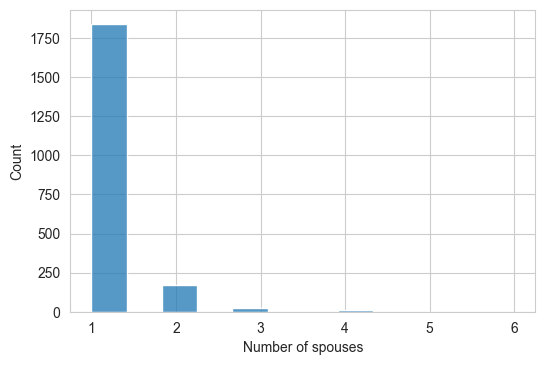

In [7]:
df_Married = df_hh_composition[df_hh_composition['Marital_status']=='Married']
df_Married = df_Married[df_Married['hhd_Relation'].isin(['Spouse', 'Household head'])]
df_Married_count = df_Married[['HouseID', 'Individual_family_code']].groupby('HouseID').count()# ['hhd_Relation'].value_counts()
df_Married_count = df_Married_count[df_Married_count['Individual_family_code'] > 1]
df_Married_count['Individual_family_code'] = df_Married_count['Individual_family_code']-1
df_Married_count.columns = ['Number of spouses']
fig, ax1 = plt.subplots(dpi=100)
sns.histplot(ax= ax1, data=df_Married_count, x="Number of spouses")

# Yes/No ICV

Ttest_relResult(statistic=4.1704897528099165, pvalue=3.405907818314286e-05)


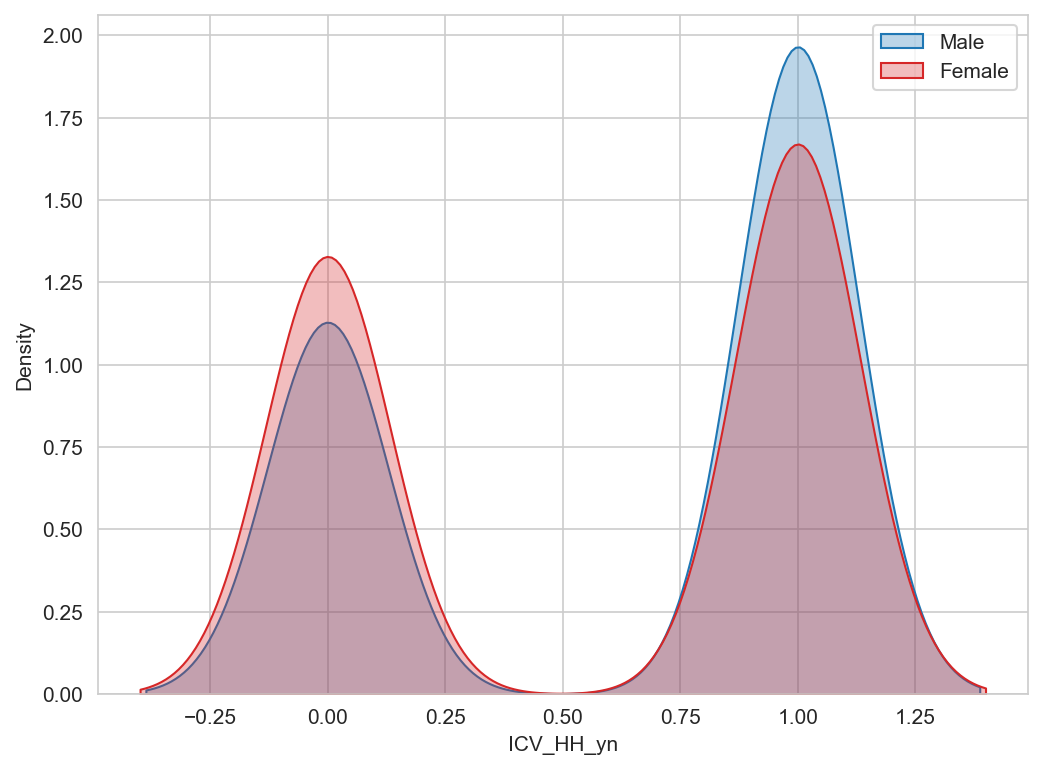

In [134]:
fig1, ax1 = plt.subplots(dpi=150, figsize=(8, 6))
sns.kdeplot(df_hh['M_ICV_HH_yn'], ax = ax1, fill=True, color="C0", label ="Male",  alpha=0.3)
sns.kdeplot(df_hh['F_ICV_HH_yn'], ax = ax1, fill=True, color="C3", label ="Female",  alpha=0.3)
ax1.set_xlabel('ICV_HH_yn')
ax1.legend()
print(ttest_rel(df_hh['M_ICV_HH_yn'], df_hh['F_ICV_HH_yn']))
fig1.savefig("../Output/Figures/ICV_HH_yn.png", dpi=100, bbox_inches='tight' )

# Total Number of ICV

Ttest_relResult(statistic=1.8276320107976824, pvalue=0.06801397112391601)


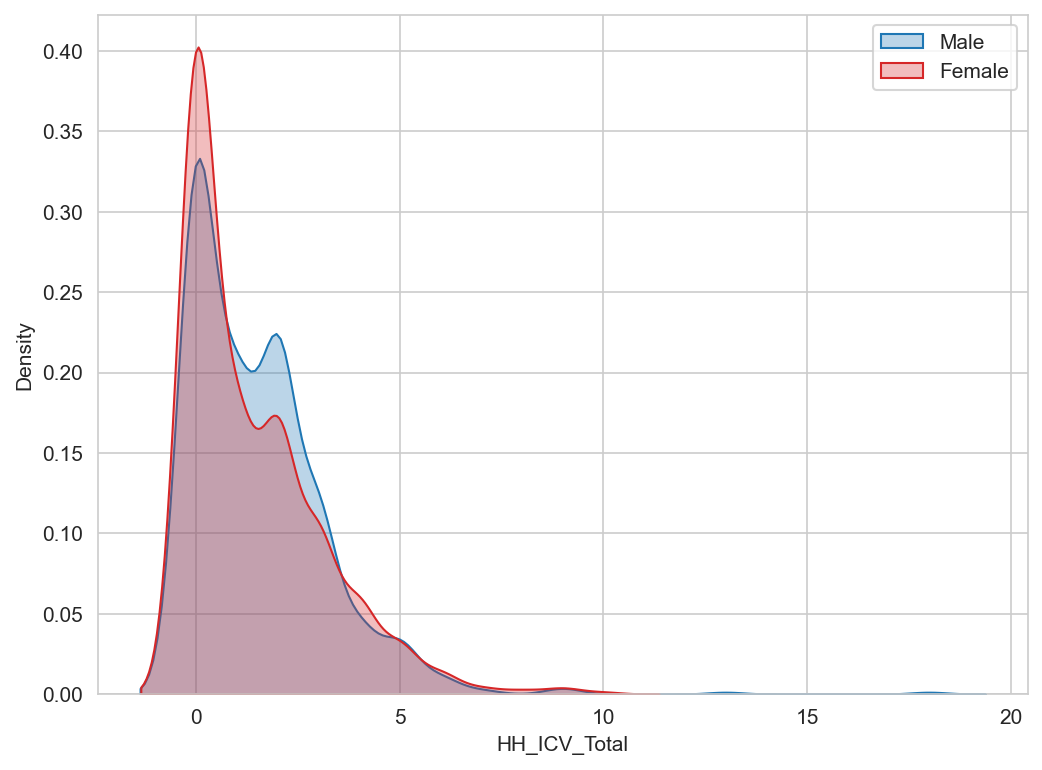

In [135]:
fig1, ax1 = plt.subplots(dpi=150, figsize=(8, 6))
sns.kdeplot(df_hh['m_tot'], ax = ax1, fill=True, color="C0", label ="Male",  alpha=0.3)
sns.kdeplot(df_hh['f_tot'], ax = ax1, fill=True, color="C3", label ="Female",  alpha=0.3)
ax1.set_xlabel('HH_ICV_Total')
ax1.legend()
print(ttest_rel(df_hh['m_tot'], df_hh['f_tot']))
fig1.savefig("../Output/Figures/HH_ICV_Total.png", dpi=100, bbox_inches='tight' )

# Age

Ttest_relResult(statistic=28.8792249394005, pvalue=8.344804813287055e-123)

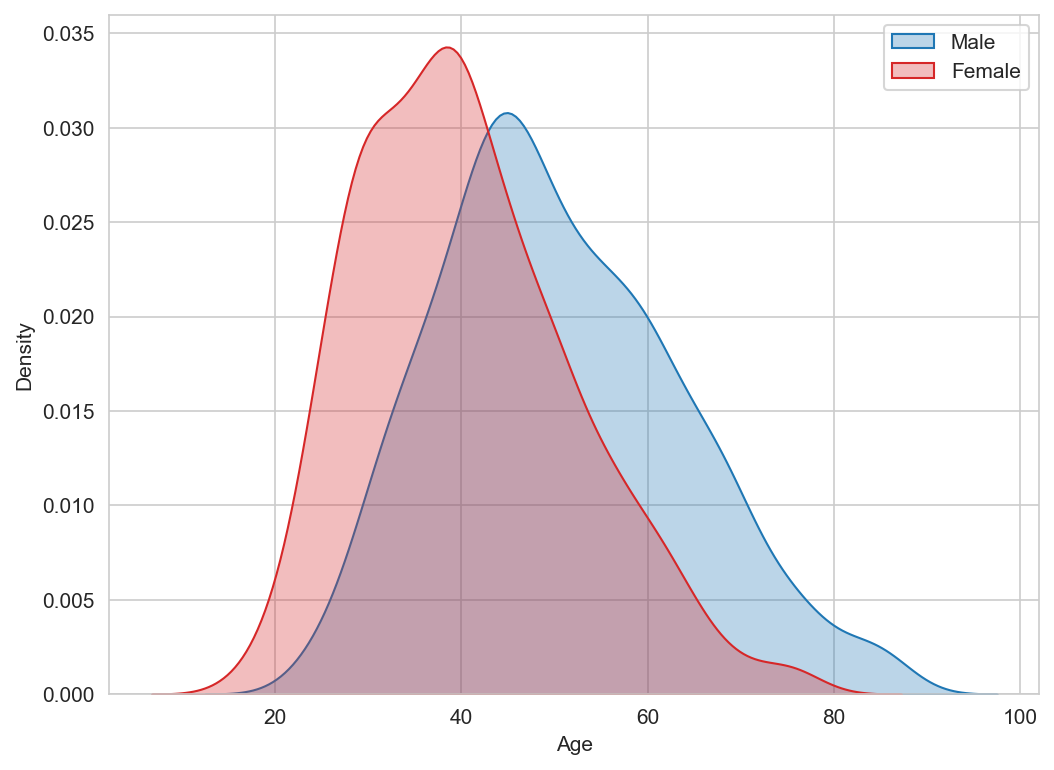

In [10]:
# 'M_ICV_HH_yn',  'M_Age', 'M_Edu', 'M_ZoneID', 'M_HHSize',  'M_Credit_HH', 'M_Cell_Own_yn', 'M_Coop_HH'
fig1, ax1 = plt.subplots(dpi=150, figsize=(8, 6))
sns.kdeplot(df_hh['M_Age'], ax = ax1, fill=True, color="C0", label ="Male",  alpha=0.3)
sns.kdeplot(df_hh['F_Age'], ax = ax1, fill=True, color="C3", label ="Female",  alpha=0.3)
ax1.set_xlabel('Age')
ax1.legend()
fig1.savefig("../Output/Figures/Age.png", dpi=100, bbox_inches='tight' )
ttest_rel(df_hh['M_Age'], df_hh['F_Age'])

# Education

Ttest_relResult(statistic=6.857545077977316, pvalue=1.4967926894371175e-11)

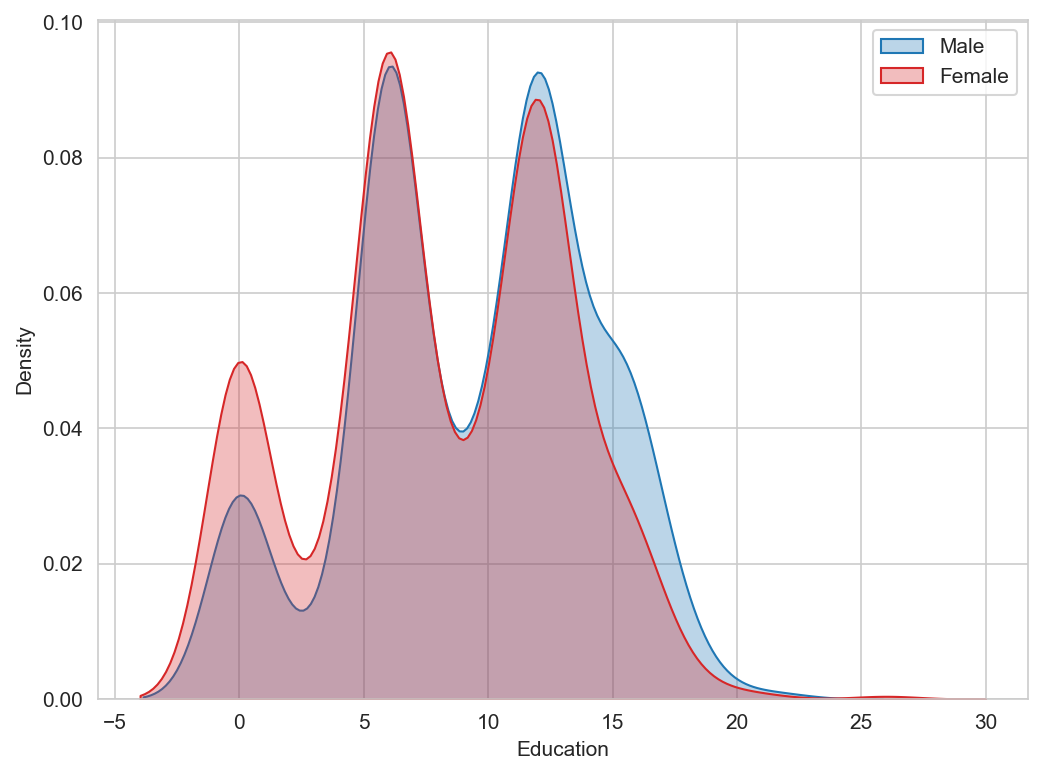

In [11]:
# 'M_ICV_HH_yn',  'M_Age', 'M_Edu', 'M_ZoneID', 'M_HHSize',  'M_Credit_HH', 'M_Cell_Own_yn', 'M_Coop_HH'
fig1, ax1 = plt.subplots(dpi=150, figsize=(8, 6))
sns.kdeplot(df_hh['M_Edu'], ax = ax1, fill=True, color="C0", label ="Male",  alpha=0.3)
sns.kdeplot(df_hh['F_Edu'], ax = ax1, fill=True, color="C3", label ="Female",  alpha=0.3)
ax1.set_xlabel('Education')
ax1.legend()
fig1.savefig("../Output/Figures/Education.png", dpi=100, bbox_inches='tight' )
ttest_rel(df_hh['M_Edu'], df_hh['F_Edu'])

# HHSize

Ttest_relResult(statistic=4.1093742423348045, pvalue=4.418357345246885e-05)

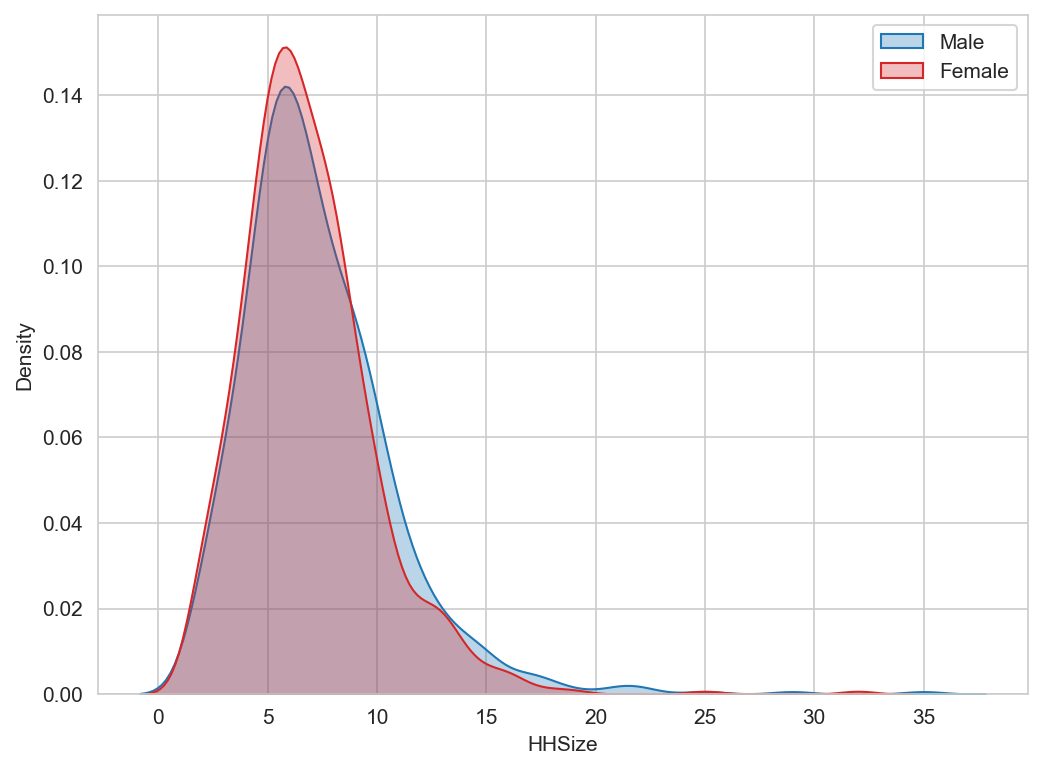

In [12]:
# 'M_ICV_HH_yn',  'M_Age', 'M_Edu', 'M_ZoneID', 'M_HHSize',  'M_Credit_HH', 'M_Cell_Own_yn', 'M_Coop_HH'
fig1, ax1 = plt.subplots(dpi=150, figsize=(8, 6))
sns.kdeplot(df_hh['M_HHSize'], ax = ax1, fill=True, color="C0", label ="Male",  alpha=0.3)
sns.kdeplot(df_hh['F_HHSize'], ax = ax1, fill=True, color="C3", label ="Female",  alpha=0.3)
ax1.set_xlabel('HHSize')
ax1.legend()
fig1.savefig("../Output/Figures/HHSize.png", dpi=100, bbox_inches='tight' )
ttest_rel(df_hh['M_HHSize'], df_hh['F_HHSize'])

# Credit_HH

Ttest_relResult(statistic=3.1929754589506243, pvalue=0.0014687433977581185)

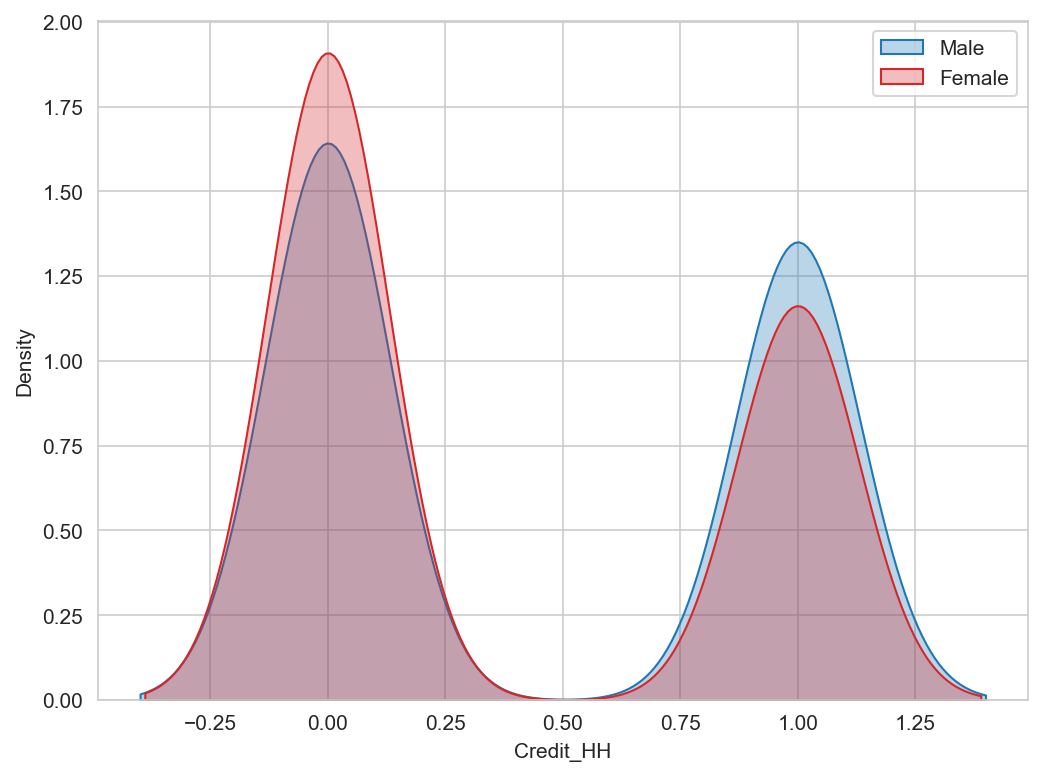

In [13]:
# 'M_ICV_HH_yn',  'M_Age', 'M_Edu', 'M_ZoneID', 'M_HHSize',  'M_Credit_HH', 'M_Cell_Own_yn', 'M_Coop_HH'
fig1, ax1 = plt.subplots(dpi=150, figsize=(8, 6))
sns.kdeplot(df_hh['M_Credit_HH'], ax = ax1, fill=True, color="C0", label ="Male",  alpha=0.3)
sns.kdeplot(df_hh['F_Credit_HH'], ax = ax1, fill=True, color="C3", label ="Female",  alpha=0.3)
ax1.set_xlabel('Credit_HH')
ax1.legend()
fig1.savefig("../Output/Figures/Credit_HH.png", dpi=100, bbox_inches='tight' )
ttest_rel(df_hh['M_Credit_HH'], df_hh['F_Credit_HH'])

# Cell_Own_yn

Ttest_relResult(statistic=0.164289237570487, pvalue=0.8695490561090478)

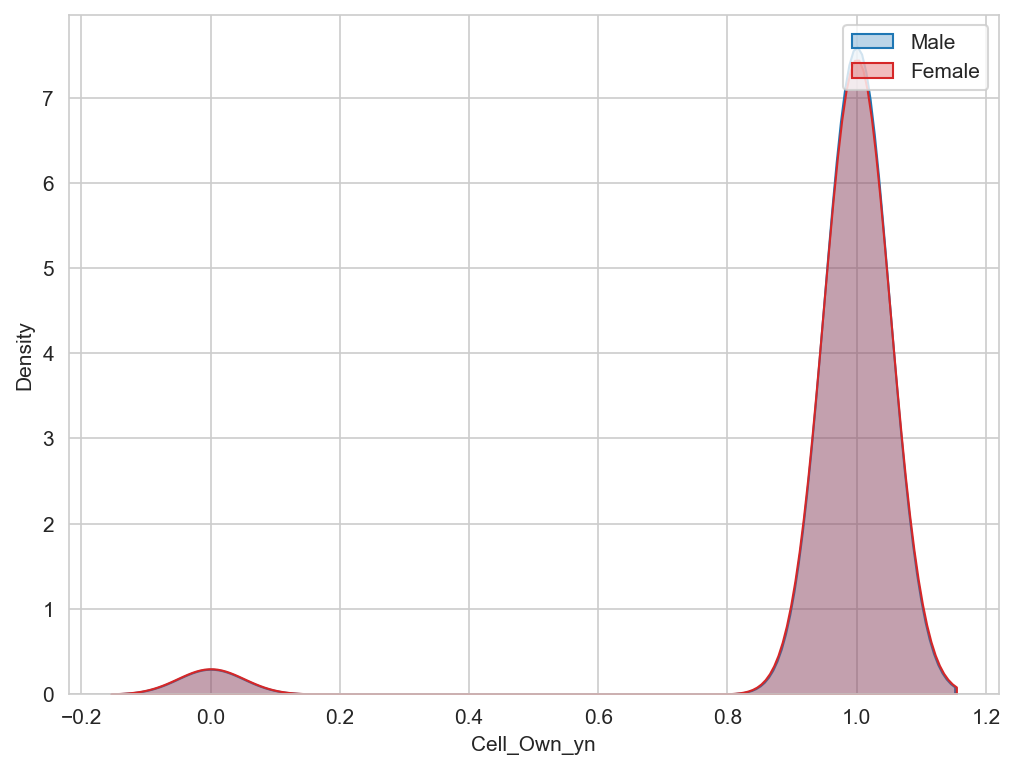

In [14]:
# 'M_ICV_HH_yn',  'M_Age', 'M_Edu', 'M_ZoneID', 'M_HHSize',  'M_Credit_HH', 'M_Cell_Own_yn', 'M_Coop_HH'
fig1, ax1 = plt.subplots(dpi=150, figsize=(8, 6))
sns.kdeplot(df_hh['M_Cell_Own_yn'], ax = ax1, fill=True, color="C0", label ="Male",  alpha=0.3)
sns.kdeplot(df_hh['F_Cell_Own_yn'], ax = ax1, fill=True, color="C3", label ="Female",  alpha=0.3)
ax1.set_xlabel('Cell_Own_yn')
ax1.legend()
fig1.savefig("../Output/Figures/Cell_Own_yn.png", dpi=100, bbox_inches='tight')
ttest_rel(df_hh['M_Cell_Own_yn'], df_hh['F_Cell_Own_yn'])

# Coop_HH

Ttest_relResult(statistic=-1.6425235331236123, pvalue=0.10091517493796158)

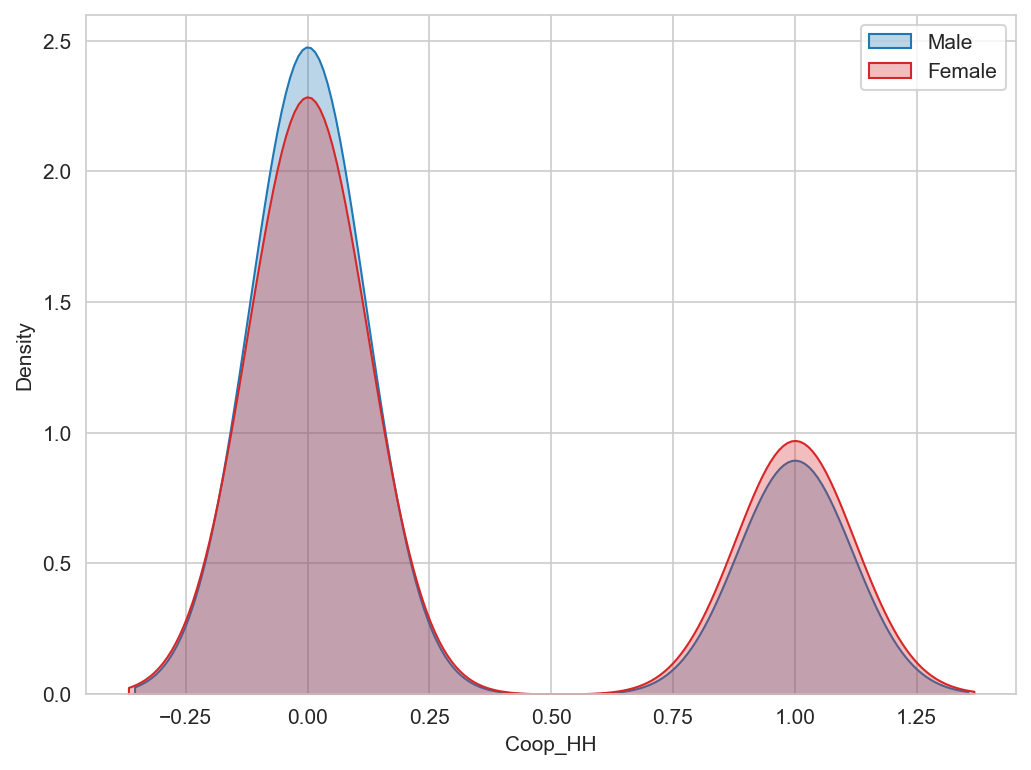

In [15]:
# 'M_ICV_HH_yn',  'M_Age', 'M_Edu', 'M_ZoneID', 'M_HHSize',  'M_Credit_HH', 'M_Cell_Own_yn', 'M_Coop_HH'
fig1, ax1 = plt.subplots(dpi=150, figsize=(8, 6))
sns.kdeplot(df_hh['M_Coop_HH'], ax = ax1, fill=True, color="C0", label ="Male",  alpha=0.3)
sns.kdeplot(df_hh['F_Coop_HH'], ax = ax1, fill=True, color="C3", label ="Female",  alpha=0.3)
ax1.set_xlabel('Coop_HH')
ax1.legend()
fig1.savefig("../Output/Figures/Coop_HH.png", dpi=100, bbox_inches='tight')
ttest_rel(df_hh['M_Coop_HH'], df_hh['F_Coop_HH'], nan_policy='omit')

# Yes/No ICV by Zone

Zone 1 Ttest_relResult(statistic=-0.8478867360080858, pvalue=0.3975967004185713)
Zone 2 Ttest_relResult(statistic=6.46746265741465, pvalue=5.644096743234074e-10)
Zone 3 Ttest_relResult(statistic=0.6871454765550714, pvalue=0.4929616033429133)
Zone 4 Ttest_relResult(statistic=0.5374456634351347, pvalue=0.5918191688480501)


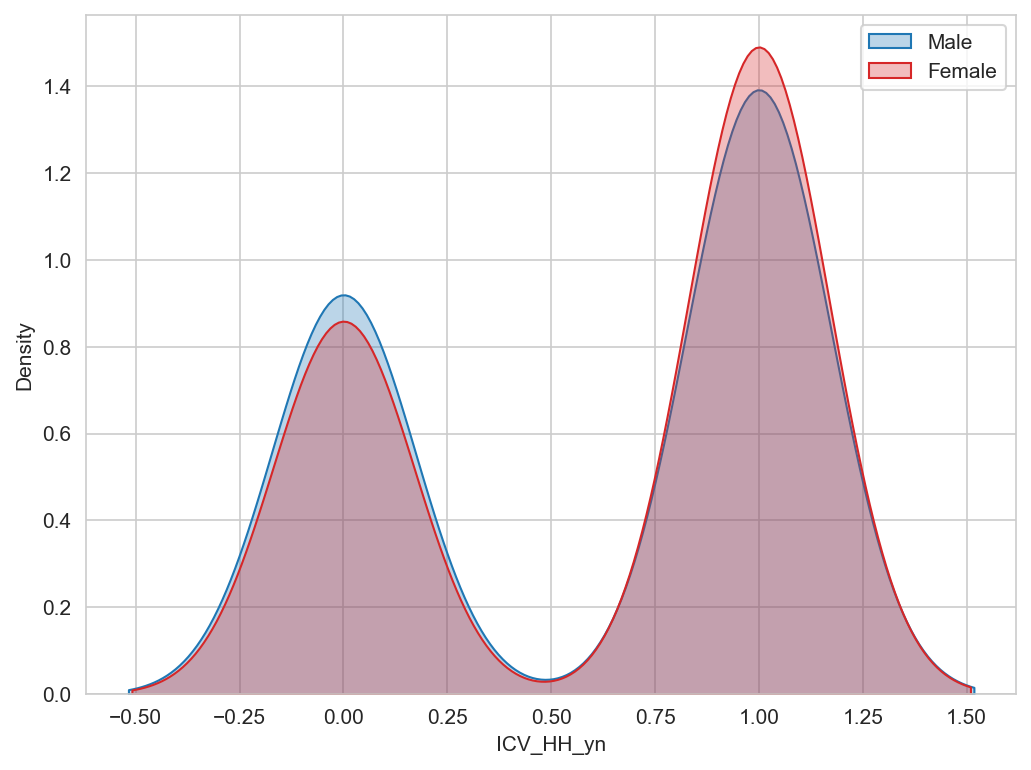

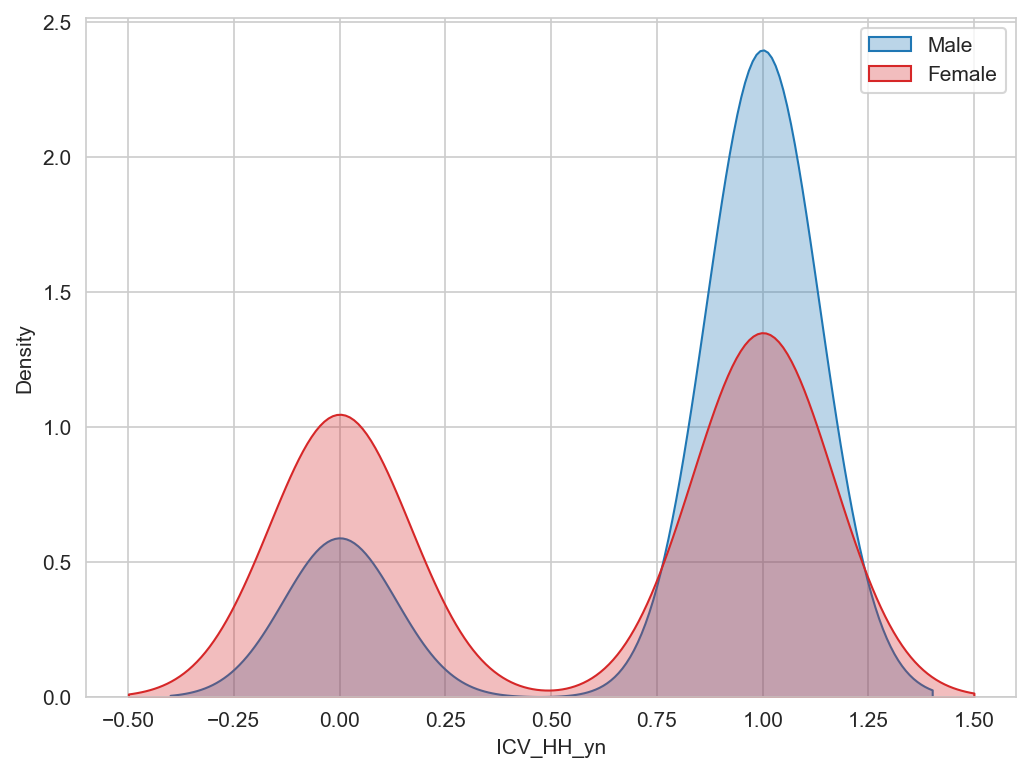

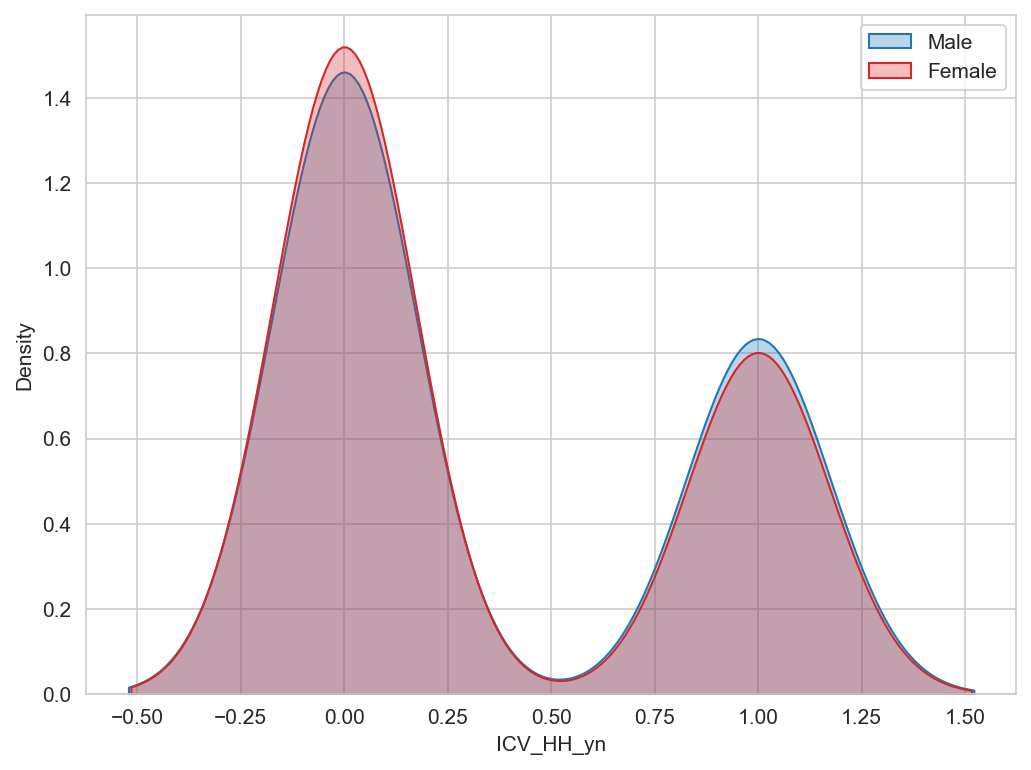

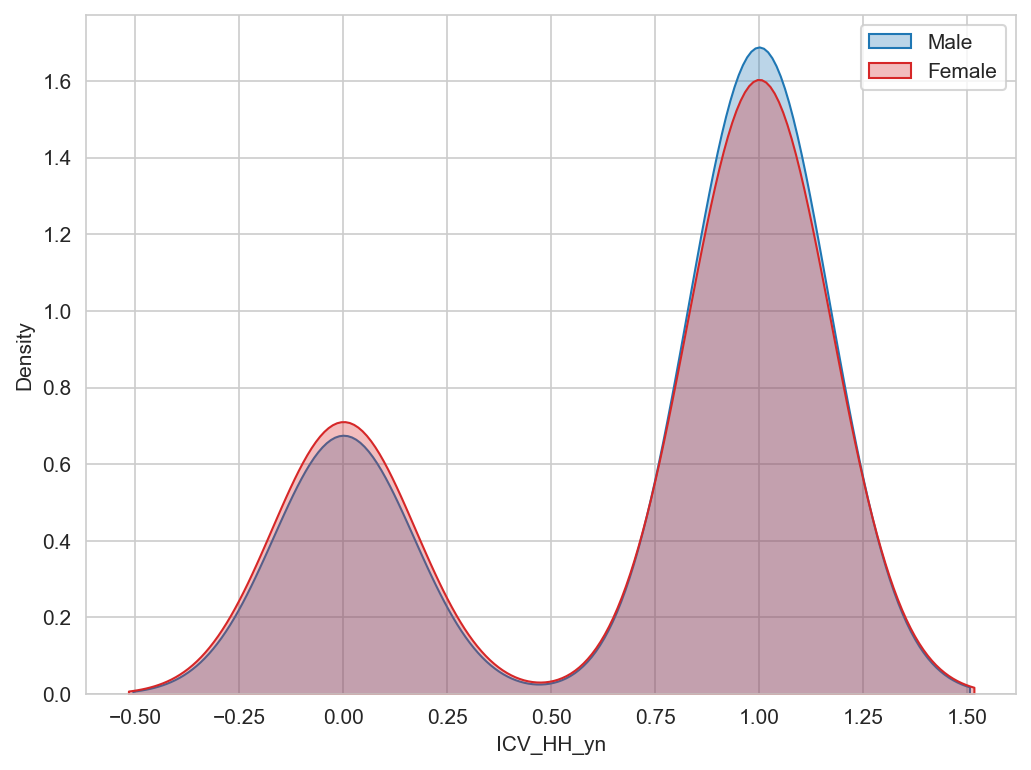

In [136]:


Zones = sorted(df_hh['M_ZoneID'].value_counts().keys())

for index, zone in enumerate(Zones):
    fig2, ax2 = plt.subplots(figsize=(8, 6), dpi=150)
    row = index//2 
    col = index%2
    df_tmp = df_hh[df_hh['M_ZoneID'] == zone]
    sns.kdeplot(df_tmp['M_ICV_HH_yn'], ax = ax2, fill=True, color="C0", label ="Male", alpha=0.3)
    sns.kdeplot(df_tmp['F_ICV_HH_yn'], ax = ax2, fill=True, color="C3", label ="Female", alpha=0.3)
    ax2.legend()
    # ax2.set_title(f'Zone {zone}', fontweight='bold')
    ax2.set_xlabel('ICV_HH_yn')
    print(f'Zone {zone}', ttest_rel(df_tmp['M_ICV_HH_yn'], df_tmp['F_ICV_HH_yn']))
    
    fig2.savefig(f"../Output/Figures/ICV_HH_yn_ZONE_{zone}.png", dpi=100, bbox_inches='tight' )

# Total Number of ICV by Zone

Zone 1 Ttest_relResult(statistic=-1.1639119706897398, pvalue=0.24595855938684302)
Zone 2 Ttest_relResult(statistic=1.690115619986353, pvalue=0.09232066457140284)
Zone 3 Ttest_relResult(statistic=1.290085052736386, pvalue=0.19883722234032908)
Zone 4 Ttest_relResult(statistic=1.621812740353948, pvalue=0.10710956464748944)


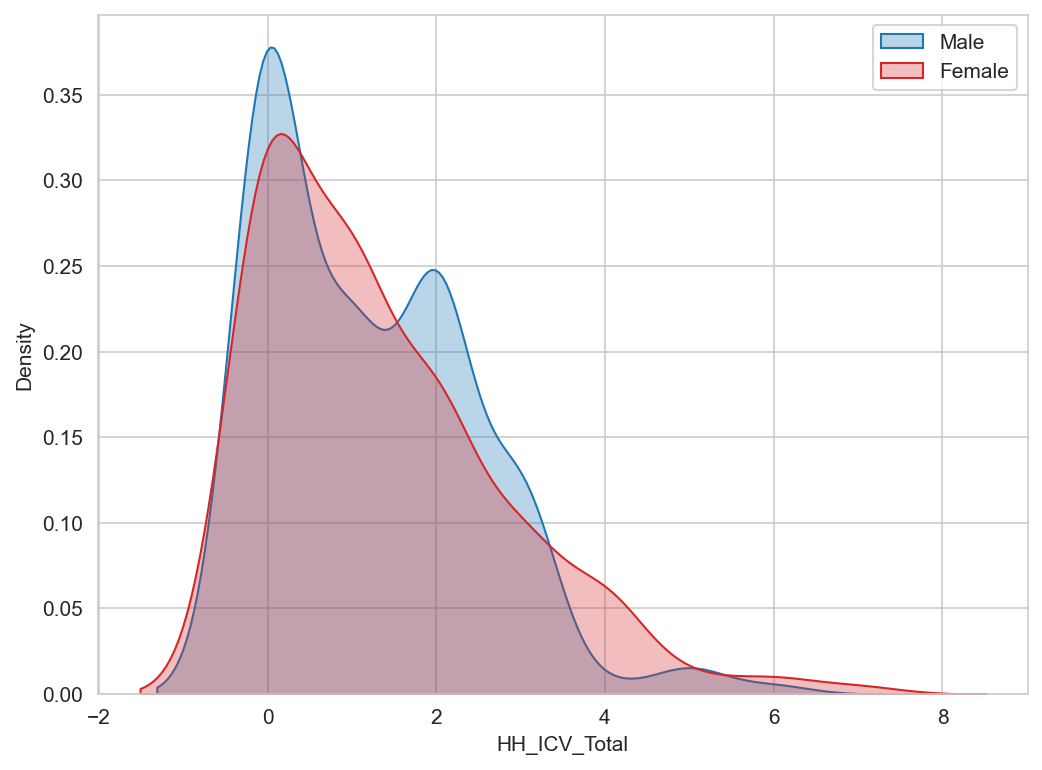

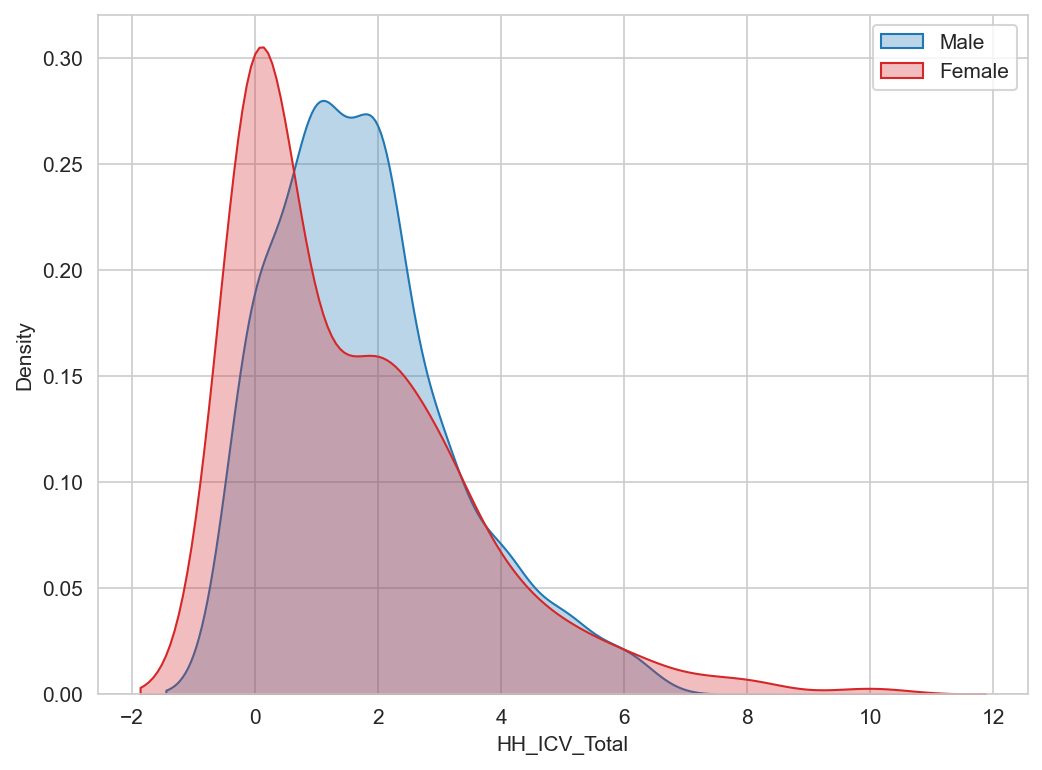

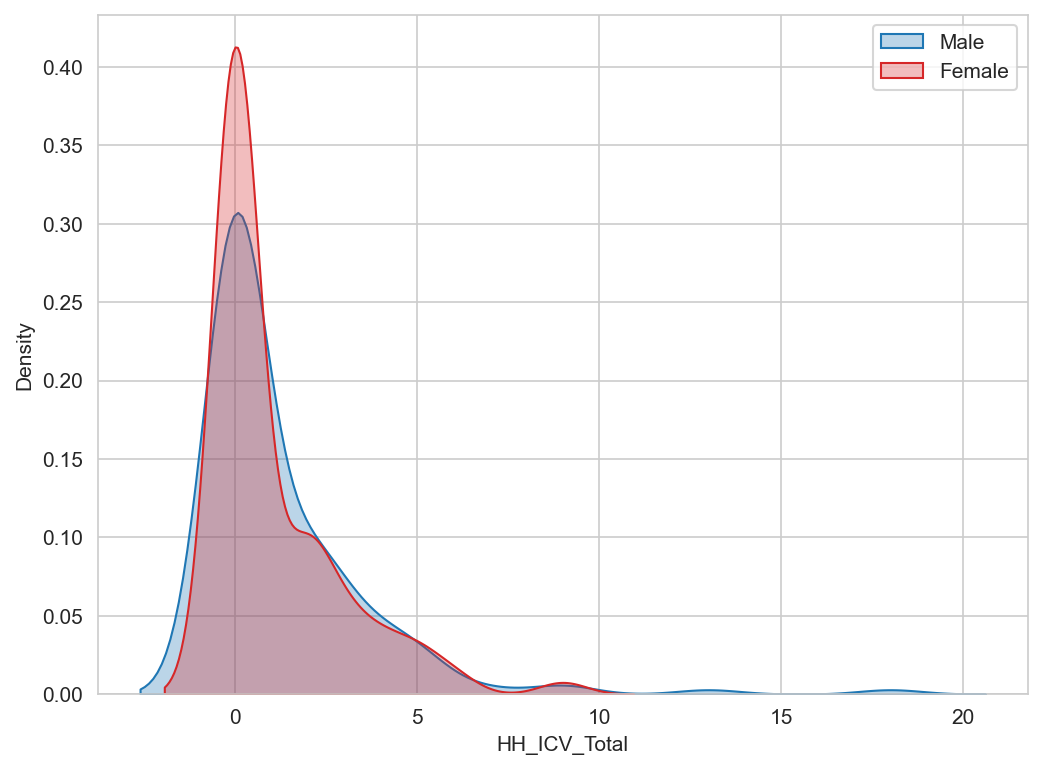

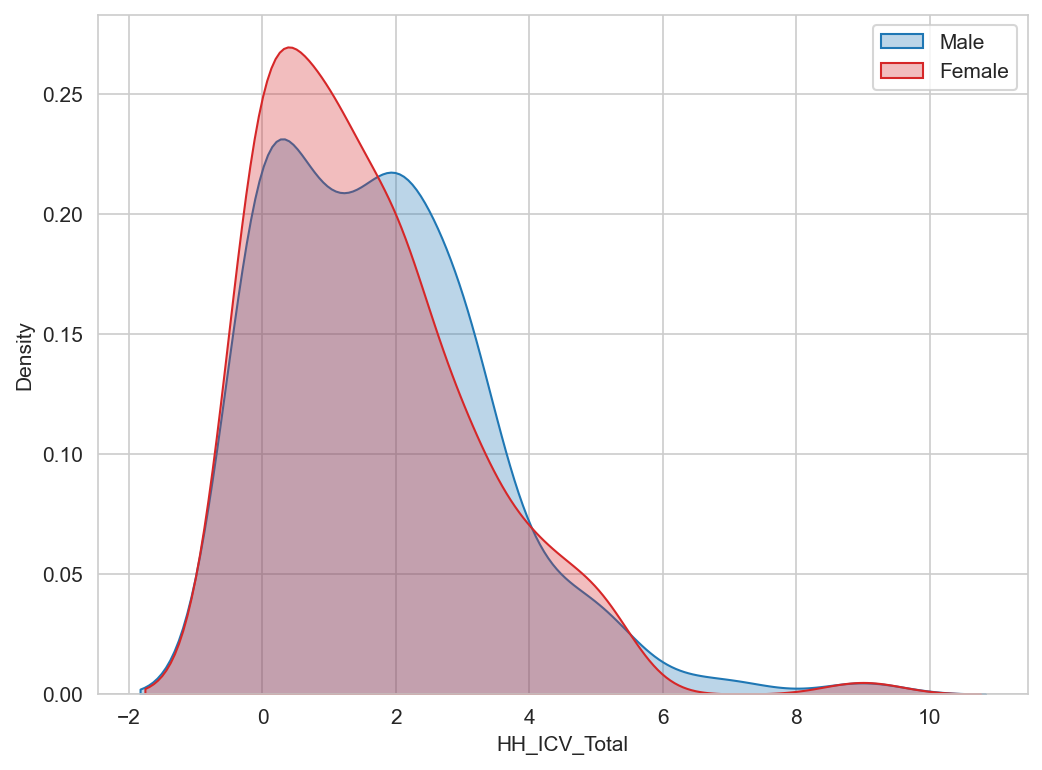

In [137]:

Zones = sorted(df_hh['M_ZoneID'].value_counts().keys())
for index, zone in enumerate(Zones):
    fig2, ax2 = plt.subplots(figsize=(8, 6), dpi=150)
    
    row = index//2 
    col = index%2
    df_tmp = df_hh[df_hh['M_ZoneID'] == zone]
    sns.kdeplot(df_tmp['m_tot'], ax = ax2, fill=True, color="C0", label ="Male", alpha=0.3)
    sns.kdeplot(df_tmp['f_tot'], ax = ax2, fill=True, color="C3", label ="Female", alpha=0.3)
    ax2.legend()
    # ax2.set_title(f'Zone {zone}', fontweight='bold')
    ax2.set_xlabel('HH_ICV_Total')
    print(f'Zone {zone}', ttest_rel(df_tmp['m_tot'], df_tmp['f_tot']))
    fig2.savefig(f"../Output/Figures/HH_ICV_Total_ZONE_{zone}.png", dpi=100, bbox_inches='tight' )

# Selecting the exogenous variables

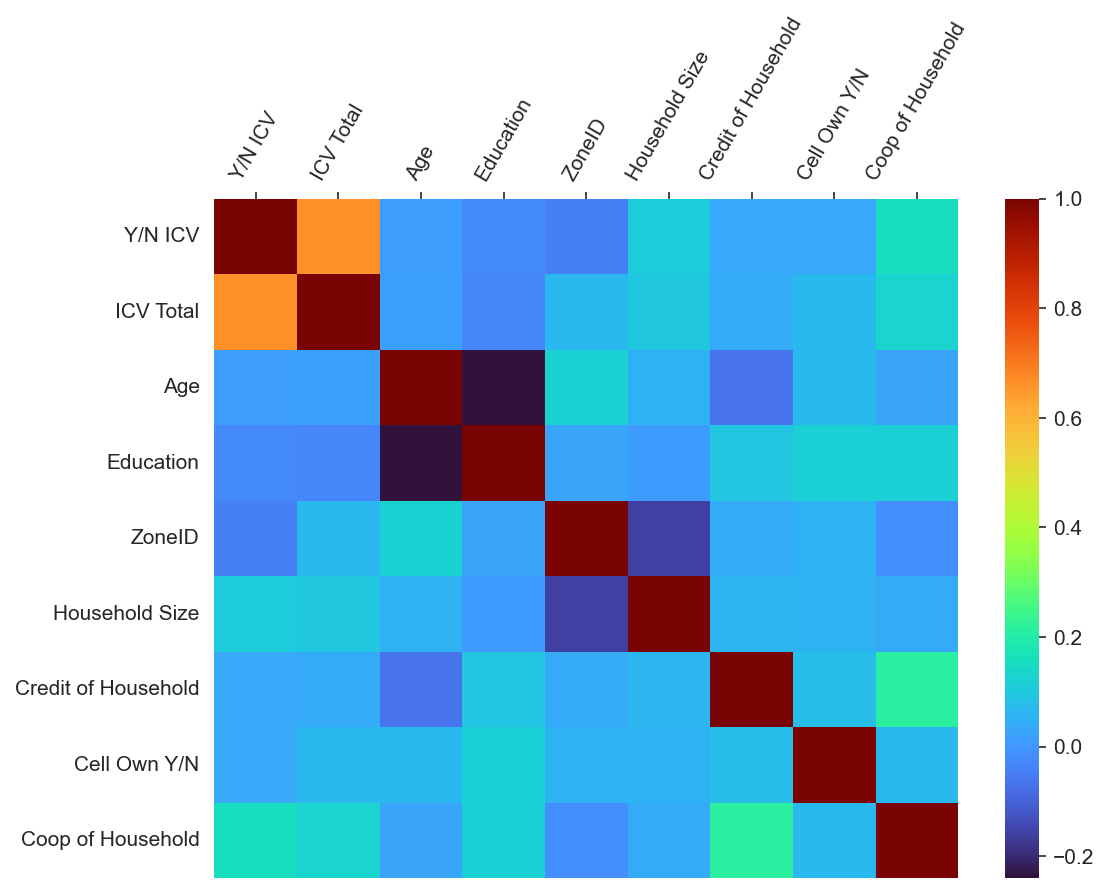

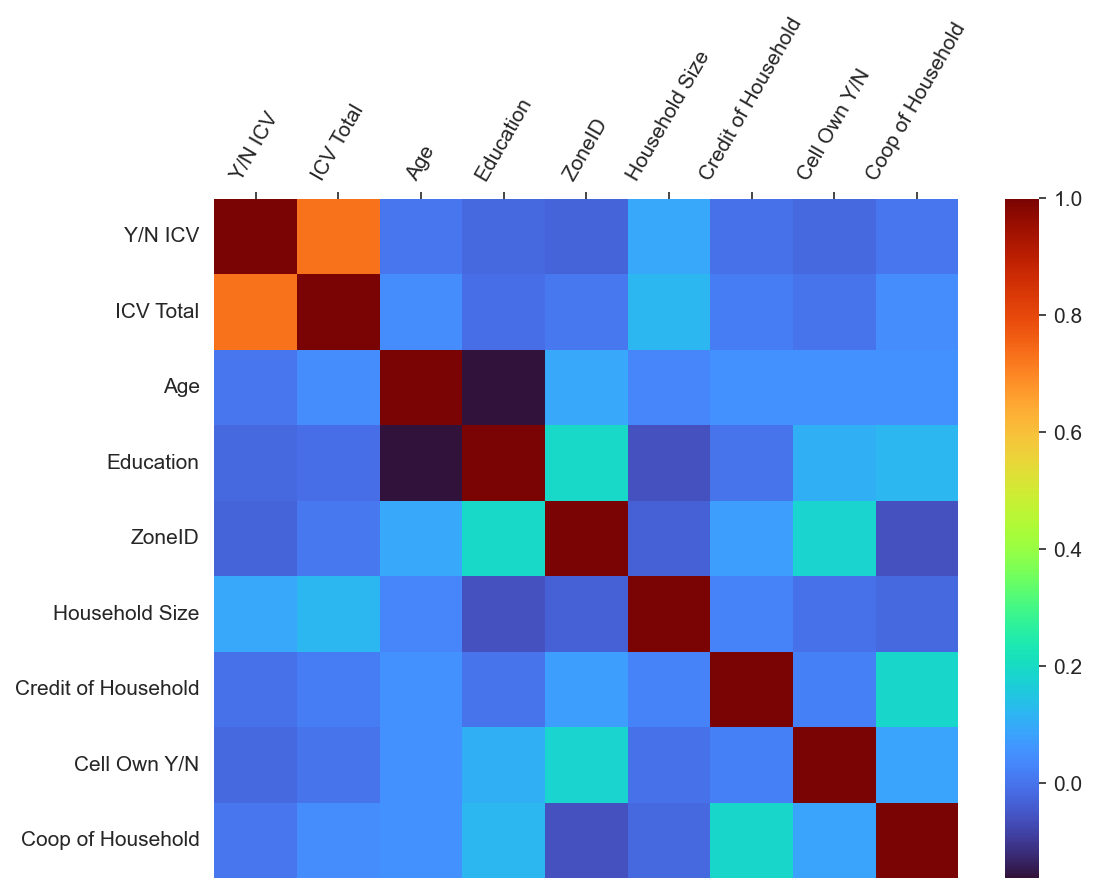

In [133]:
import matplotlib.pyplot as plt

for gender in ['M', 'F']:
    fig3, ax3 = plt.subplots(figsize=(8, 6), dpi=150)
    df_data  = df_hh[[f'{gender}_ICV_HH_yn', f'{gender.lower()}_tot',
                      f'{gender}_Age', f'{gender}_Edu', f'{gender}_ZoneID', 
                      f'{gender}_HHSize', f'{gender}_Credit_HH', f'{gender}_Cell_Own_yn', f'{gender}_Coop_HH']]

    df_data.columns = ['Y/N ICV', 'ICV Total', 'Age', 'Education', 'ZoneID', 
                       'Household Size', "Credit of Household", "Cell Own Y/N", "Coop of Household"]
    
    corr = df_data.corr()
    sns.heatmap(corr, 
                ax=ax3,
                xticklabels=corr.columns.values,
                yticklabels=corr.columns.values,
               cmap="turbo")
    ax3.xaxis.tick_top()
    ax3.set_xticklabels(df_data.columns,  rotation=60)
    fig3.savefig(f"../Output/Figures/Correlation_{gender}.png", dpi=100, bbox_inches='tight' )

# Y/N ICV - Regression

In [257]:
def make_regression(X, Y, Gender, LPM=True, Probit=True, Logit=True, add_column=True, replace=True):
    df_results = []
    # Linear probability model
    if LPM:
        model_1 = sm.OLS(Y,X)
        results_1 = model_1.fit(cov_type='HC0')
        df_results_LPM = pd.concat([results_1.params, results_1.bse, results_1.pvalues], axis=1)
        df_results_LPM['LPM'] = df_results_LPM.apply(lambda x: convert_pvalue_to_asterisks(x), axis=1)
        df_results_LPM = df_results_LPM.drop([0, 1, 2], axis=1)
        df_results.append(df_results_LPM)
    # Probit
    if Probit:
        model_2 = sm.Probit(Y,X)
        results_2 = model_2.fit(cov_type='HC0', disp=False)
        df_results_Probit = pd.concat([results_2.params, results_2.bse, results_2.pvalues], axis=1)
        df_results_Probit['Probit'] = df_results_Probit.apply(lambda x: convert_pvalue_to_asterisks(x), axis=1)
        df_results_Probit = df_results_Probit.drop([0, 1, 2], axis=1)
        df_results.append(df_results_Probit)

    # Logit
    if Logit:
        model_3 = sm.Logit(Y,X)
        results_3 = model_3.fit(cov_type='HC0', disp=False)
        df_results_Logit = pd.concat([results_3.params, results_3.bse, results_3.pvalues], axis=1)
        df_results_Logit['Logit'] = df_results_Logit.apply(lambda x: convert_pvalue_to_asterisks(x), axis=1)
        df_results_Logit = df_results_Logit.drop([0, 1, 2], axis=1)
        df_results.append(df_results_Logit)
    
    df_results = pd.concat(df_results, axis=1)
    if add_column:
        df_results['-----'] = ''
        
    if replace:
        df_results.index = [i.replace(f"{Gender}_", "") for i in df_results.index]
    return df_results

def clean_exog(df, gender, dummies=True):
    dd_hh = df.copy()
    #dd_hh[f'{gender}_HHAsset_Value_Total_lg'] = dd_hh[f'{gender}_HHAsset_Value_Total'].apply(lambda x: np.log(x))
    #dd_hh = dd_hh.drop([f'{gender}_HHAsset_Value_Total'], axis=1)
    if dummies:
        zone_ID_dummies = pd.get_dummies(dd_hh[f'{gender}_ZoneID'])
        zone_ID_dummies.columns = [f'Zone {i}' for i in zone_ID_dummies.columns]
        dd_hh = pd.concat([dd_hh, zone_ID_dummies], axis=1)
        dd_hh = dd_hh.drop(['Zone 1'], axis=1)
        dd_hh = dd_hh.drop([f'{gender}_ZoneID'], axis=1)
        
    dd_hh = dd_hh.replace([np.inf, -np.inf], np.nan)
    dd_hh = dd_hh.dropna()
    return dd_hh.astype(float)

dictionary_var = {
    'const': "Constant", 
    'HH_yn': "Y/N ICV", 
    'Age': "Age",
    'Edu': "Education",
    'HHSize': "Household Size",
    'Credit_HH': "Credit of Household",
    'Cell_Own_yn': "Cell Own Y/N",
    'Coop_HH': "Coop of Household"
}

In [242]:
##########################################################################################
# MALE REGRESSION
##########################################################################################
dd_hh_M = df_hh[['M_ICV_HH_yn',  'M_Age', 'M_Edu', 'M_ZoneID', 'M_HHSize', 
                 'M_Credit_HH', 'M_Cell_Own_yn', 'M_Coop_HH']]
#dd_hh_M = df_hh[['M_ICV_HH_yn', 'M_HHSize', 'M_Credit_HH', 'M_Cell_Own_yn', 'M_Coop_HH']]


dd_hh_M = clean_exog(dd_hh_M, 'M', dummies=True)
X = dd_hh_M[dd_hh_M.columns[1:]] 
X = sm.add_constant(X)
Y = dd_hh_M['M_ICV_HH_yn']

df_hh_results_Male = make_regression(X, Y, 'M', LPM=False, Probit=True, Logit=False, add_column=False)

##########################################################################################
# FEMALE REGRESSION
##########################################################################################
dd_hh_F = df_hh[['F_ICV_HH_yn',  'F_Age', 'F_Edu', 'F_ZoneID', 'F_HHSize', 
                 'F_Credit_HH', 'F_Cell_Own_yn', 'F_Coop_HH']]
#dd_hh_F = df_hh[['F_ICV_HH_yn',  'F_HHSize', 'F_Credit_HH', 'F_Cell_Own_yn', 'F_Coop_HH']]

dd_hh_F = clean_exog(dd_hh_F, 'F', dummies=True)
X = dd_hh_F[dd_hh_F.columns[1:]] 
X = sm.add_constant(X)
Y = dd_hh_F['F_ICV_HH_yn']

df_hh_results_Female = make_regression(X, Y, 'F', LPM=False, Probit=True, Logit=False, add_column=False)

##########################################################################################
# JOIN RESULTS
##########################################################################################
df_hh_results_yn_ICV = pd.concat([df_hh_results_Male, df_hh_results_Female], axis=1)
df_hh_results_yn_ICV

,Probit,Probit
const,-0.546 (0.368),-0.105 (0.314)
Age,0.004 (0.004),0.007 (0.004)
Edu,-0.013 (0.011),0.003 (0.010)
HHSize,0.041 (0.015) ***,0.029 (0.016) *
Credit_HH,-0.048 (0.105),-0.059 (0.103)
Cell_Own_yn,0.376 (0.274),-0.014 (0.247)
Coop_HH,0.334 (0.125) ***,-0.024 (0.110)
Zone 2,0.569 (0.140) ***,-0.163 (0.137)
Zone 3,-0.614 (0.150) ***,-0.778 (0.150) ***
Zone 4,0.322 (0.152) **,0.160 (0.153)


In [259]:
##########################################################################################
# JOINT REGRESSION
##########################################################################################
df_hh_results_joint = []
for gender in ['M', 'F']:
    dd_hh_M = df_hh[[f'{gender}_ICV_HH_yn',  
                     f'{gender}_Age', f'{gender}_Edu', f'{gender}_ZoneID', f'{gender}_HHSize', 
                     f'{gender}_Credit_HH', f'{gender}_Cell_Own_yn', f'{gender}_Coop_HH']]

    dd_hh_M = clean_exog(dd_hh_M, gender=gender, dummies=True)
    X = dd_hh_M[dd_hh_M.columns[1:]] 
    print(X.keys())
    X = sm.add_constant(X)
    Y = dd_hh_M[f'{gender}_ICV_HH_yn']

    
    df_hh_results_M = make_regression(X, Y, gender, LPM=False, Probit=True, Logit=False, 
                                      add_column=False, replace=False)
    df_hh_results_joint.append(df_hh_results_M)


##########################################################################################
# JOIN RESULTS
##########################################################################################
df_hh_results_joint = pd.concat(df_hh_results_joint, axis=1)
df_hh_results_joint

Index(['M_Age', 'M_Edu', 'M_HHSize', 'M_Credit_HH', 'M_Cell_Own_yn',
       'M_Coop_HH', 'Zone 2', 'Zone 3', 'Zone 4'],
      dtype='object')
Index(['F_Age', 'F_Edu', 'F_HHSize', 'F_Credit_HH', 'F_Cell_Own_yn',
       'F_Coop_HH', 'Zone 2', 'Zone 3', 'Zone 4'],
      dtype='object')


,Probit,Probit
const,-0.546 (0.368),-0.105 (0.314)
M_Age,0.004 (0.004),NaN
M_Edu,-0.013 (0.011),NaN
M_HHSize,0.041 (0.015) ***,NaN
M_Credit_HH,-0.048 (0.105),NaN
M_Cell_Own_yn,0.376 (0.274),NaN
M_Coop_HH,0.334 (0.125) ***,NaN
Zone 2,0.569 (0.140) ***,-0.163 (0.137)
Zone 3,-0.614 (0.150) ***,-0.778 (0.150) ***
Zone 4,0.322 (0.152) **,0.160 (0.153)


# Total Number of ICV - Regression

In [167]:
##########################################################################################
# MALE REGRESSION
##########################################################################################
#dd_hh_M = df_hh[['m_tot',  'M_Age', 'M_Edu', 'M_ZoneID', 'M_HHSize', 
#                 'M_Credit_HH', 'M_Cell_Own_yn', 'M_Coop_HH']]
dd_hh_M = df_hh[['m_tot',  'M_HHSize', 'M_Credit_HH', 'M_Cell_Own_yn', 'M_Coop_HH']]

dd_hh_M = clean_exog(dd_hh_M, 'M', dummies=False)
X = dd_hh_M[dd_hh_M.columns[1:]] 
X = sm.add_constant(X)
Y = dd_hh_M['m_tot']

df_hh_results_Male = make_regression(X, Y, 'M', LPM=True, Probit=False, Logit=False, add_column=False)

##########################################################################################
# FEMALE REGRESSION
##########################################################################################
#dd_hh_F = df_hh[['f_tot',  'F_Age', 'F_Edu',  'F_ZoneID', 'F_HHSize', 
#                 'F_Credit_HH', 'F_Cell_Own_yn', 'F_Coop_HH']]
dd_hh_F = df_hh[['f_tot', 'F_HHSize', 'F_Credit_HH', 'F_Cell_Own_yn', 'F_Coop_HH']]

dd_hh_F = clean_exog(dd_hh_F, 'F', dummies=False)
X = dd_hh_F[dd_hh_F.columns[1:]] 
X = sm.add_constant(X)
Y = dd_hh_F['f_tot']

df_hh_results_Female = make_regression(X, Y, 'F', LPM=True, Probit=False, Logit=False, add_column=False)

##########################################################################################
# JOIN RESULTS
##########################################################################################
df_hh_results_ICV_total = pd.concat([df_hh_results_Male, df_hh_results_Female], axis=1)
df_hh_results_ICV_total

,LPM,LPM
const,0.566 (0.219) ***,0.897 (0.331) ***
HHSize,0.048 (0.015) ***,0.068 (0.025) ***
Credit_HH,0.029 (0.125),0.019 (0.131)
Cell_Own_yn,0.490 (0.208) **,-0.035 (0.298)
Coop_HH,0.447 (0.145) ***,0.164 (0.146)


In [145]:
print('\\begin{tabular}{lcccc}')
print("\hline")
print("& \\multicolumn{2}{c}{Y/N ICV} & \\multicolumn{2}{c}{ICV Total}\\\\")
print(" & Male & Female & Male & Female \\\\")
print("\hline")

for index, row_yn_ICV, row_ICV_total in zip(df_hh_results_ICV_total.index, 
                                            df_hh_results_yn_ICV.values, 
                                            df_hh_results_ICV_total.values):
    
    mean_fixed_values_yn_ICV = ["".join(row_yn_ICV[0].split(" ")[::2]), 
                                "".join(row_yn_ICV[1].split(" ")[::2])]
    std_fixed_values_yn_ICV  = ["".join(row_yn_ICV[0].split(" ")[1]), 
                                "".join(row_yn_ICV[1].split(" ")[1])]
    mean_fixed_values_ICV_total = ["".join(row_ICV_total[0].split(" ")[::2]), 
                                "".join(row_ICV_total[1].split(" ")[::2])]
    std_fixed_values_ICV_total  = ["".join(row_ICV_total[0].split(" ")[1]), 
                                "".join(row_ICV_total[1].split(" ")[1])]
    
    var = dictionary_var[index] if index in dictionary_var else index
    print("\\multirow{2}{*}{" + f"{var}" + "} & " + "& ".join(mean_fixed_values_yn_ICV) +  "&" + "& ".join(mean_fixed_values_ICV_total) +" \\\\")
    print(" &" + " & ".join(std_fixed_values_yn_ICV) + "&" + " & ".join(std_fixed_values_ICV_total) + " \\\\")
print("\hline")
print("\end{tabular}")

\begin{tabular}{lcccc}
\hline
& \multicolumn{2}{c}{Y/N ICV} & \multicolumn{2}{c}{ICV Total}\\
 & Male & Female & Male & Female \\
\hline
\multirow{2}{*}{Constant} & -0.546& -0.105&0.323& 0.580 \\
 &(0.368) & (0.314)&(0.353) & (0.386) \\
\multirow{2}{*}{Age} & 0.004& 0.007&-0.001& 0.008 \\
 &(0.004) & (0.004)&(0.005) & (0.006) \\
\multirow{2}{*}{Education} & -0.013& 0.003&-0.019& 0.002 \\
 &(0.011) & (0.010)&(0.015) & (0.013) \\
\multirow{2}{*}{Household Size} & 0.041***& 0.029*&0.058***& 0.068*** \\
 &(0.015) & (0.016)&(0.016) & (0.025) \\
\multirow{2}{*}{Credit of Household} & -0.048& -0.059&0.002& -0.076 \\
 &(0.105) & (0.103)&(0.123) & (0.131) \\
\multirow{2}{*}{Cell Own Y/N} & 0.376& -0.014&0.594***& -0.073 \\
 &(0.274) & (0.247)&(0.230) & (0.302) \\
\multirow{2}{*}{Coop of Household} & 0.334***& -0.024&0.385**& 0.097 \\
 &(0.125) & (0.110)&(0.151) & (0.153) \\
\multirow{2}{*}{Zone 2} & 0.569***& -0.163&0.565***& 0.280* \\
 &(0.140) & (0.137)&(0.135) & (0.170) \\
\multirow{2}{*}{Zo

In [146]:
for index, row_yn_ICV, row_ICV_total in zip(df_hh_results_ICV_total.index, 
                                            df_hh_results_yn_ICV.values, 
                                            df_hh_results_ICV_total.values):
    
    mean_fixed_values_yn_ICV = ["".join(row_yn_ICV[0].split(" ")[::2]), 
                                "".join(row_yn_ICV[1].split(" ")[::2])]
    std_fixed_values_yn_ICV  = ["".join(row_yn_ICV[0].split(" ")[1]), 
                                "".join(row_yn_ICV[1].split(" ")[1])]
    mean_fixed_values_ICV_total = ["".join(row_ICV_total[0].split(" ")[::2]), 
                                "".join(row_ICV_total[1].split(" ")[::2])]
    std_fixed_values_ICV_total  = ["".join(row_ICV_total[0].split(" ")[1]), 
                                "".join(row_ICV_total[1].split(" ")[1])]
    
    var = dictionary_var[index] if index in dictionary_var else index
    print( f"{var}" + "," + ", ".join(mean_fixed_values_yn_ICV) +  "," + ", ".join(mean_fixed_values_ICV_total) )
    print(" ," + " , ".join(std_fixed_values_yn_ICV) + "," + " , ".join(std_fixed_values_ICV_total) )

Constant,-0.546, -0.105,0.323, 0.580
 ,(0.368) , (0.314),(0.353) , (0.386)
Age,0.004, 0.007,-0.001, 0.008
 ,(0.004) , (0.004),(0.005) , (0.006)
Education,-0.013, 0.003,-0.019, 0.002
 ,(0.011) , (0.010),(0.015) , (0.013)
Household Size,0.041***, 0.029*,0.058***, 0.068***
 ,(0.015) , (0.016),(0.016) , (0.025)
Credit of Household,-0.048, -0.059,0.002, -0.076
 ,(0.105) , (0.103),(0.123) , (0.131)
Cell Own Y/N,0.376, -0.014,0.594***, -0.073
 ,(0.274) , (0.247),(0.230) , (0.302)
Coop of Household,0.334***, -0.024,0.385**, 0.097
 ,(0.125) , (0.110),(0.151) , (0.153)
Zone 2,0.569***, -0.163,0.565***, 0.280*
 ,(0.140) , (0.137),(0.135) , (0.170)
Zone 3,-0.614***, -0.778***,0.151, -0.257
 ,(0.150) , (0.150),(0.209) , (0.192)
Zone 4,0.322**, 0.160,0.612***, 0.268
 ,(0.152) , (0.153),(0.168) , (0.178)


# Y/N ICV by Zones - Regression

In [148]:
df_hh_results = []

Zones = sorted(df_hh['M_ZoneID'].value_counts().keys())
for index, zone in enumerate(Zones):
    ##########################################################################################
    # MALE REGRESSION
    ##########################################################################################
    df_hh_M_z1 = df_hh[df_hh['M_ZoneID'] == zone]
    df_hh_M_z1 = df_hh_M_z1[['M_ICV_HH_yn',  'M_Age', 'M_Edu', 'M_HHSize', 
                          'M_Credit_HH', 'M_Cell_Own_yn', 'M_Coop_HH']]

    dd_hh_M = clean_exog(df_hh_M_z1, 'M', dummies=False)
    X = dd_hh_M[dd_hh_M.columns[1:]] 
    X = sm.add_constant(X)
    Y = dd_hh_M['M_ICV_HH_yn']

    df_hh_results_Male = make_regression(X, Y, 'M', LPM=False, Probit=True, Logit=False, add_column=False)
    df_hh_results_Male.columns = [f'Z{zone}-M']
    df_hh_results.append(df_hh_results_Male)

    ##########################################################################################
    # FEMALE REGRESSION
    ##########################################################################################
    dd_hh_F_z1 = df_hh[df_hh['F_ZoneID'] == zone]
    dd_hh_F_z1 = dd_hh_F_z1[['F_ICV_HH_yn',  'F_Age', 'F_Edu', 'F_HHSize', 
                             'F_Credit_HH', 'F_Cell_Own_yn', 'F_Coop_HH']]

    dd_hh_F = clean_exog(dd_hh_F_z1, 'F', dummies=False)
    X = dd_hh_F[dd_hh_F.columns[1:]] 
    X = sm.add_constant(X)
    Y = dd_hh_F['F_ICV_HH_yn']

    df_hh_results_Female = make_regression(X, Y, 'F', LPM=False, Probit=True, Logit=False, add_column=False)
    df_hh_results_Female.columns = [f'Z{zone}-F']
    # df_hh_results_Female['-'] = ''
    df_hh_results.append(df_hh_results_Female)


##########################################################################################
# JOIN RESULTS
##########################################################################################
df_hh_results_yn_ICV_zone = pd.concat(df_hh_results, axis=1)
df_hh_results_yn_ICV_zone

,Z1-M,Z1-F,Z2-M,Z2-F,Z3-M,Z3-F,Z4-M,Z4-F
const,0.249 (0.606),0.361 (0.484),-1.735 (0.729) **,-1.481 (0.651) **,-6.379 (0.465) ***,-7.239 (0.650) ***,0.185 (0.847),-6.751 (0.616) ***
Age,0.006 (0.009),-0.005 (0.009),0.025 (0.009) ***,0.023 (0.008) ***,-0.007 (0.007),0.002 (0.009),-0.003 (0.011),0.007 (0.011)
Edu,-0.008 (0.020),-0.024 (0.018),-0.010 (0.022),0.011 (0.017),-0.012 (0.026),0.029 (0.027),-0.044 (0.029),0.026 (0.026)
HHSize,0.076 (0.026) ***,0.092 (0.031) ***,0.056 (0.039),-0.005 (0.032),0.018 (0.039),0.021 (0.039),0.014 (0.044),0.011 (0.042)
Credit_HH,-0.045 (0.204),0.277 (0.247),0.036 (0.218),0.034 (0.171),-0.236 (0.226),-0.290 (0.233),0.036 (0.237),-0.237 (0.236)
Cell_Own_yn,-0.919 (0.492) *,-0.366 (0.334),1.001 (0.389) **,0.633 (0.516),6.452 (0.164) ***,6.418 (0.153) ***,0.933 (0.582),6.697 (0.211) ***
Coop_HH,0.530 (0.255) **,-0.217 (0.237),0.379 (0.238),0.008 (0.170),0.337 (0.279),-0.030 (0.256),0.083 (0.262),0.318 (0.270)


In [154]:
Zones = sorted(df_hh['M_ZoneID'].value_counts().keys())

print('\\begin{tabular}{lcccccccc}')
print("\hline")
print("\\multicolumn{9}{c}{\\textbf{Dependent Variable: Y/N ICV}} \\\\")
print("\hline")
print(" &" + " & ".join(["\\multicolumn{2}{c}{" + f"Zone {zone}" + "}"  for zone in Zones]) + "\\\\")
print(" &" + " & ".join([f'{"Male" if i%2 == 0 else "Female"}' for i in range(len(Zones)*2)]) + "\\\\")
print("\hline")
for index, row in zip(df_hh_results_yn_ICV_zone.index, df_hh_results_yn_ICV_zone.values):
    mean_fixed_values = ["".join(row[i].split(" ")[::2]) for i in range(len(row))]
    std_fixed_values = ["".join(row[0].split(" ")[1]) for i in range(len(row))]
    var = dictionary_var[index] if index in dictionary_var else index
    print("\\multirow{2}{*}{" + f"{var}" + "} & " + "& ".join(mean_fixed_values) + " \\\\")
    print(" &" + " & ".join(std_fixed_values) + " \\\\")
print("\hline")
print("\end{tabular}")

\begin{tabular}{lcccccccc}
\hline
\multicolumn{9}{c}{\textbf{Dependent Variable: Y/N ICV}} \\
\hline
 &\multicolumn{2}{c}{Zone 1} & \multicolumn{2}{c}{Zone 2} & \multicolumn{2}{c}{Zone 3} & \multicolumn{2}{c}{Zone 4}\\
 &Male & Female & Male & Female & Male & Female & Male & Female\\
\hline
\multirow{2}{*}{Constant} & 0.249& 0.361& -1.735**& -1.481**& -6.379***& -7.239***& 0.185& -6.751*** \\
 &(0.606) & (0.606) & (0.606) & (0.606) & (0.606) & (0.606) & (0.606) & (0.606) \\
\multirow{2}{*}{Age} & 0.006& -0.005& 0.025***& 0.023***& -0.007& 0.002& -0.003& 0.007 \\
 &(0.009) & (0.009) & (0.009) & (0.009) & (0.009) & (0.009) & (0.009) & (0.009) \\
\multirow{2}{*}{Education} & -0.008& -0.024& -0.010& 0.011& -0.012& 0.029& -0.044& 0.026 \\
 &(0.020) & (0.020) & (0.020) & (0.020) & (0.020) & (0.020) & (0.020) & (0.020) \\
\multirow{2}{*}{Household Size} & 0.076***& 0.092***& 0.056& -0.005& 0.018& 0.021& 0.014& 0.011 \\
 &(0.026) & (0.026) & (0.026) & (0.026) & (0.026) & (0.026) & (0.026) & (0

In [162]:
for index, row_yn_ICV in zip(df_hh_results_yn_ICV_zone.index, 
                            df_hh_results_yn_ICV_zone.values):
    
    mean_fixed_values = ["".join(row_yn_ICV[i].split(" ")[::2]) for i in range(len(row))]
    std_fixed_values = ["".join(row_yn_ICV[i].split(" ")[1]) for i in range(len(row))]
    var = dictionary_var[index] if index in dictionary_var else index
    print( f"{var}" + "," + ", ".join(mean_fixed_values) )
    print(" ," + " , ".join(std_fixed_values)  )

Constant,0.249, 0.361, -1.735**, -1.481**, -6.379***, -7.239***, 0.185, -6.751***
 ,(0.606) , (0.484) , (0.729) , (0.651) , (0.465) , (0.650) , (0.847) , (0.616)
Age,0.006, -0.005, 0.025***, 0.023***, -0.007, 0.002, -0.003, 0.007
 ,(0.009) , (0.009) , (0.009) , (0.008) , (0.007) , (0.009) , (0.011) , (0.011)
Education,-0.008, -0.024, -0.010, 0.011, -0.012, 0.029, -0.044, 0.026
 ,(0.020) , (0.018) , (0.022) , (0.017) , (0.026) , (0.027) , (0.029) , (0.026)
Household Size,0.076***, 0.092***, 0.056, -0.005, 0.018, 0.021, 0.014, 0.011
 ,(0.026) , (0.031) , (0.039) , (0.032) , (0.039) , (0.039) , (0.044) , (0.042)
Credit of Household,-0.045, 0.277, 0.036, 0.034, -0.236, -0.290, 0.036, -0.237
 ,(0.204) , (0.247) , (0.218) , (0.171) , (0.226) , (0.233) , (0.237) , (0.236)
Cell Own Y/N,-0.919*, -0.366, 1.001**, 0.633, 6.452***, 6.418***, 0.933, 6.697***
 ,(0.492) , (0.334) , (0.389) , (0.516) , (0.164) , (0.153) , (0.582) , (0.211)
Coop of Household,0.530**, -0.217, 0.379, 0.008, 0.337, -0.030

# Total Number of ICV - Regression

In [157]:
df_hh_results = []

Zones = sorted(df_hh['M_ZoneID'].value_counts().keys())

for index, zone in enumerate(Zones):
    ##########################################################################################
    # MALE REGRESSION
    ##########################################################################################
    df_hh_M_z1 = df_hh[df_hh['M_ZoneID'] == zone]
    df_hh_M_z1 = df_hh_M_z1[['m_tot',  'M_Age', 'M_Edu', 'M_HHSize', 
                          'M_Credit_HH', 'M_Cell_Own_yn', 'M_Coop_HH']]

    dd_hh_M = clean_exog(df_hh_M_z1, 'M', dummies=False)
    X = dd_hh_M[dd_hh_M.columns[1:]] 
    X = sm.add_constant(X)
    Y = dd_hh_M['m_tot']

    df_hh_results_Male = make_regression(X, Y, 'M', LPM=True, Probit=False, Logit=False, add_column=False)
    df_hh_results_Male.columns = [f'Z{zone}-M']
    df_hh_results.append(df_hh_results_Male)

    ##########################################################################################
    # FEMALE REGRESSION
    ##########################################################################################
    dd_hh_F_z1 = df_hh[df_hh['F_ZoneID'] == zone]
    dd_hh_F_z1 = dd_hh_F_z1[['f_tot',  'F_Age', 'F_Edu', 'F_HHSize', 
                             'F_Credit_HH', 'F_Cell_Own_yn', 'F_Coop_HH']]

    dd_hh_F = clean_exog(dd_hh_F_z1, 'F', dummies=False)
    X = dd_hh_F[dd_hh_F.columns[1:]] 
    X = sm.add_constant(X)
    Y = dd_hh_F['f_tot']

    df_hh_results_Female = make_regression(X, Y, 'F', LPM=True, Probit=False, Logit=False, add_column=False)
    df_hh_results_Female.columns = [f'Z{zone}-F']
    df_hh_results.append(df_hh_results_Female)


##########################################################################################
# JOIN RESULTS
##########################################################################################
df_hh_results_ICV_total = pd.concat(df_hh_results, axis=1)
df_hh_results_ICV_total

,Z1-M,Z1-F,Z2-M,Z2-F,Z3-M,Z3-F,Z4-M,Z4-F
const,0.965 (0.421) **,0.630 (0.512),-0.611 (0.621),-1.265 (0.623) **,0.385 (0.763),-0.205 (0.809),1.522 (0.841) *,0.220 (0.657)
Age,-0.005 (0.007),0.004 (0.009),0.017 (0.008) **,0.033 (0.011) ***,-0.010 (0.012),-0.007 (0.012),-0.019 (0.012),-0.007 (0.011)
Edu,-0.007 (0.018),0.014 (0.018),-0.008 (0.021),-0.019 (0.023),-0.054 (0.064),0.037 (0.035),-0.024 (0.031),-0.005 (0.028)
HHSize,0.072 (0.017) ***,0.117 (0.036) ***,0.073 (0.033) **,0.078 (0.053),0.067 (0.068),0.010 (0.051),0.058 (0.061),0.028 (0.050)
Credit_HH,-0.033 (0.184),-0.237 (0.201),0.210 (0.185),0.174 (0.238),-0.176 (0.361),-0.263 (0.316),-0.251 (0.282),-0.088 (0.263)
Cell_Own_yn,-0.139 (0.326),-0.408 (0.372),0.935 (0.339) ***,0.981 (0.415) **,1.392 (0.364) ***,1.180 (0.210) ***,1.130 (0.492) **,1.442 (0.214) ***
Coop_HH,0.348 (0.205) *,-0.131 (0.275),0.232 (0.193),0.045 (0.241),0.794 (0.594),0.220 (0.411),0.223 (0.325),0.300 (0.302)


In [160]:
Zones = sorted(df_hh['M_ZoneID'].value_counts().keys())

print('\\begin{tabular}{lcccccccc}')
print("\hline")
print("\\multicolumn{9}{c}{\\textbf{Dependent Variable: ICV Total}} \\\\")
print("\hline")
print(" &" + " & ".join(["\\multicolumn{2}{c}{" + f"Zone {zone}" + "}"  for zone in Zones]) + "\\\\")
print(" &" + " & ".join([f'{"Male" if i%2 == 0 else "Female"}' for i in range(len(Zones)*2)]) + "\\\\")
print("\hline")
for index, row in zip(df_hh_results_ICV_total.index, df_hh_results_ICV_total.values):
    mean_fixed_values = ["".join(row[i].split(" ")[::2]) for i in range(len(row))]
    std_fixed_values = ["".join(row[i].split(" ")[1]) for i in range(len(row))]
    var = dictionary_var[index] if index in dictionary_var else index
    print("\\multirow{2}{*}{" + f"{var}" + "} & " + "& ".join(mean_fixed_values) + " \\\\")
    print(" &" + " & ".join(std_fixed_values) + " \\\\")
print("\hline")
print("\end{tabular}")

\begin{tabular}{lcccccccc}
\hline
\multicolumn{9}{c}{\textbf{Dependent Variable: ICV Total}} \\
\hline
 &\multicolumn{2}{c}{Zone 1} & \multicolumn{2}{c}{Zone 2} & \multicolumn{2}{c}{Zone 3} & \multicolumn{2}{c}{Zone 4}\\
 &Male & Female & Male & Female & Male & Female & Male & Female\\
\hline
\multirow{2}{*}{Constant} & 0.965**& 0.630& -0.611& -1.265**& 0.385& -0.205& 1.522*& 0.220 \\
 &(0.421) & (0.512) & (0.621) & (0.623) & (0.763) & (0.809) & (0.841) & (0.657) \\
\multirow{2}{*}{Age} & -0.005& 0.004& 0.017**& 0.033***& -0.010& -0.007& -0.019& -0.007 \\
 &(0.007) & (0.009) & (0.008) & (0.011) & (0.012) & (0.012) & (0.012) & (0.011) \\
\multirow{2}{*}{Education} & -0.007& 0.014& -0.008& -0.019& -0.054& 0.037& -0.024& -0.005 \\
 &(0.018) & (0.018) & (0.021) & (0.023) & (0.064) & (0.035) & (0.031) & (0.028) \\
\multirow{2}{*}{Household Size} & 0.072***& 0.117***& 0.073**& 0.078& 0.067& 0.010& 0.058& 0.028 \\
 &(0.017) & (0.036) & (0.033) & (0.053) & (0.068) & (0.051) & (0.061) & (0.050)

In [163]:
for index, row_yn_ICV in zip(df_hh_results_ICV_total.index, 
                            df_hh_results_ICV_total.values):
    
    mean_fixed_values = ["".join(row_yn_ICV[i].split(" ")[::2]) for i in range(len(row))]
    std_fixed_values = ["".join(row_yn_ICV[i].split(" ")[1]) for i in range(len(row))]
    var = dictionary_var[index] if index in dictionary_var else index
    print( f"{var}" + "," + ", ".join(mean_fixed_values) )
    print(" ," + " , ".join(std_fixed_values)  )

Constant,0.965**, 0.630, -0.611, -1.265**, 0.385, -0.205, 1.522*, 0.220
 ,(0.421) , (0.512) , (0.621) , (0.623) , (0.763) , (0.809) , (0.841) , (0.657)
Age,-0.005, 0.004, 0.017**, 0.033***, -0.010, -0.007, -0.019, -0.007
 ,(0.007) , (0.009) , (0.008) , (0.011) , (0.012) , (0.012) , (0.012) , (0.011)
Education,-0.007, 0.014, -0.008, -0.019, -0.054, 0.037, -0.024, -0.005
 ,(0.018) , (0.018) , (0.021) , (0.023) , (0.064) , (0.035) , (0.031) , (0.028)
Household Size,0.072***, 0.117***, 0.073**, 0.078, 0.067, 0.010, 0.058, 0.028
 ,(0.017) , (0.036) , (0.033) , (0.053) , (0.068) , (0.051) , (0.061) , (0.050)
Credit of Household,-0.033, -0.237, 0.210, 0.174, -0.176, -0.263, -0.251, -0.088
 ,(0.184) , (0.201) , (0.185) , (0.238) , (0.361) , (0.316) , (0.282) , (0.263)
Cell Own Y/N,-0.139, -0.408, 0.935***, 0.981**, 1.392***, 1.180***, 1.130**, 1.442***
 ,(0.326) , (0.372) , (0.339) , (0.415) , (0.364) , (0.210) , (0.492) , (0.214)
Coop of Household,0.348*, -0.131, 0.232, 0.045, 0.794, 0.220, 0

# Montecarlo Simulations

In [204]:
#########################################################################
# Create pseudo-datasets with different percentage of Male/female answers
# input: Dataset and percentage of female answers
# output: pseudo-dataset with the ICV_HH_yn values and Adop_rate.
#########################################################################
def sudo_share(df,rate):
    # print(df.shape)
    num = int(df.shape[0]*rate)
    df_sample_fe =  df.sample(num)
    df_sample_ma = df.drop(df_sample_fe.index)
    df_sample_i = np.concatenate((df_sample_fe['F_ICV_HH_yn'].values, df_sample_ma['M_ICV_HH_yn'].values))
    df_sample_i = pd.DataFrame(df_sample_i, columns=['ICV_HH_yn'])
    Adop_rate = df_sample_i.sum() / df.shape[0]
    return [df_sample_i, Adop_rate]

In [230]:
df_mc_results = []
for i in range(1000):
    df_sudo = []
    df_adop_rate = []
    for percentage in np.arange(0, 1.1, 0.1):
        df_sample, adop_rate = sudo_share(df_hh, round(percentage, 1))
        df_sudo.append(df_sample)
        df_adop_rate.append(adop_rate)

    df_sudo = pd.concat(df_sudo, axis=1)
    df_sudo.columns = ['0','10','20','30','40','50','60','70','80','90','100']
    df_adop_rate = pd.concat(df_adop_rate, axis=1)
    df_adop_rate.columns = ['0','10','20','30','40','50','60','70','80','90','100']
    df_mc_results.append(df_adop_rate)
    
df_mc_results = pd.concat(df_mc_results)
df_mc_results = df_mc_results.reset_index(drop=True)
df_mc_results

,0,10,20,30,40,50,60,70,80,90,100
0,0.635117,0.628258,0.600823,0.603567,0.604938,0.595336,0.599451,0.588477,0.577503,0.574760,0.556927
1,0.635117,0.635117,0.625514,0.614540,0.606310,0.588477,0.587106,0.576132,0.570645,0.559671,0.556927
2,0.635117,0.617284,0.628258,0.618656,0.609053,0.596708,0.592593,0.581619,0.574760,0.562414,0.556927
3,0.635117,0.622771,0.628258,0.624143,0.615912,0.602195,0.592593,0.573388,0.574760,0.561043,0.556927
4,0.635117,0.626886,0.621399,0.617284,0.609053,0.588477,0.589849,0.573388,0.556927,0.563786,0.556927
...,...,...,...,...,...,...,...,...,...,...,...
995,0.635117,0.615912,0.617284,0.599451,0.603567,0.609053,0.600823,0.593964,0.562414,0.559671,0.556927
996,0.635117,0.629630,0.617284,0.617284,0.606310,0.592593,0.576132,0.581619,0.585734,0.550069,0.556927
997,0.635117,0.615912,0.641975,0.621399,0.604938,0.602195,0.584362,0.563786,0.577503,0.573388,0.556927
998,0.635117,0.617284,0.624143,0.606310,0.607682,0.596708,0.584362,0.587106,0.584362,0.559671,0.556927


In [229]:
import random as rand

# Weighted selection: p_i is the probability of selecting element i
def weighted(p):
    y = rand.random()
    k=0
    while k<len(p) and y>=p[k]:
        y -= p[k]
        k+=1
    return k

p = (df_hh['M_ZoneID'].value_counts()/df_hh['M_ZoneID'].value_counts().sum()).sort_index().values

df_mc_results_cluster = []
for i in range(1000):
    df_sudo = []
    df_adop_rate = []
    for percentage in np.arange(0, 1.1, 0.1):
        selected_cluster = weighted(p) + 1
        df_sample, adop_rate = sudo_share(df_hh[df_hh['M_ZoneID'] == selected_cluster], round(percentage, 1))
        df_sudo.append(df_sample)
        df_adop_rate.append(adop_rate)

    df_sudo = pd.concat(df_sudo, axis=1)
    df_sudo.columns = ['0','10','20','30','40','50','60','70','80','90','100']
    df_adop_rate = pd.concat(df_adop_rate, axis=1)
    df_adop_rate.columns = ['0','10','20','30','40','50','60','70','80','90','100']
    df_mc_results_cluster.append(df_adop_rate)
    
df_mc_results_cluster = pd.concat(df_mc_results_cluster)
df_mc_results_cluster = df_mc_results_cluster.reset_index(drop=True)
df_mc_results_cluster

,0,10,20,30,40,50,60,70,80,90,100
0,0.714286,0.375758,0.586022,0.714286,0.629032,0.339394,0.659664,0.351515,0.600840,0.618280,0.345455
1,0.802521,0.596774,0.768908,0.357576,0.351515,0.629032,0.591398,0.339394,0.618280,0.685714,0.634409
2,0.363636,0.602151,0.618280,0.629032,0.591398,0.714286,0.651261,0.618280,0.621849,0.618280,0.563025
3,0.602151,0.728571,0.618280,0.714286,0.714286,0.629032,0.333333,0.351515,0.678571,0.339394,0.345455
4,0.802521,0.714286,0.363636,0.602151,0.363636,0.629032,0.680672,0.351515,0.621849,0.345455,0.563025
...,...,...,...,...,...,...,...,...,...,...,...
995,0.602151,0.714286,0.777311,0.756303,0.580645,0.693277,0.351515,0.661290,0.605042,0.623656,0.692857
996,0.714286,0.363636,0.357576,0.692857,0.680672,0.718487,0.629032,0.642857,0.623656,0.339394,0.634409
997,0.802521,0.721429,0.739496,0.602151,0.602151,0.710084,0.655462,0.623656,0.626050,0.707143,0.634409
998,0.363636,0.707143,0.760504,0.714286,0.700000,0.642857,0.375758,0.638655,0.609244,0.579832,0.634409


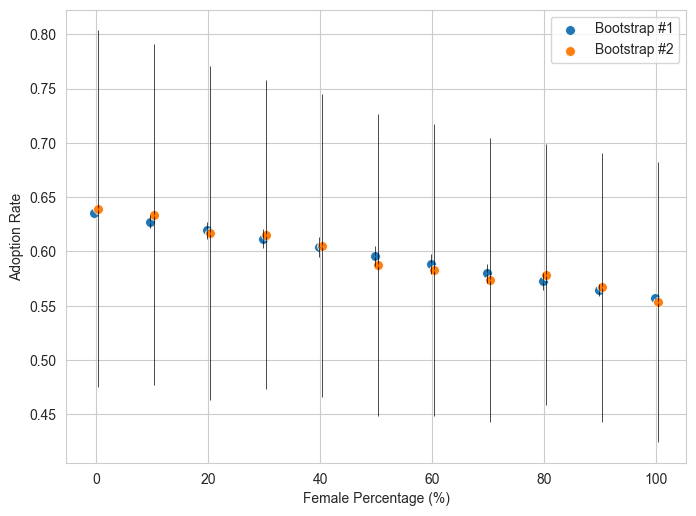

In [232]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
df_mc = [df_mc_results, df_mc_results_cluster]
for index, tmp_df, label in zip([-1, 1], df_mc,['Bootstrap #1', 'Bootstrap #2']):
    df_mc_results_mean = tmp_df.mean()
    df_mc_results_mean = df_mc_results_mean.reset_index()
    
    df_mc_results_mean.columns = ['Percentage', 'Adoption Rate']
    df_mc_results_mean['Percentage'] = df_mc_results_mean['Percentage'].astype(int) + index*0.3

    df_mc_results_std = tmp_df.std()
    df_mc_results_std = df_mc_results_std.reset_index()
    df_mc_results_std.columns = ['Percentage', 'Adoption Rate']
    df_mc_results_std['Percentage'] = 0
    

    ax.errorbar(x=df_mc_results_mean['Percentage'], 
                y=df_mc_results_mean['Adoption Rate'], 
                yerr=df_mc_results_std['Adoption Rate'],
                fmt='.', 
                # color="C0", 
                ecolor="black", 
                elinewidth=0.5,  ms=1)

    sns.scatterplot(
                ax = ax, 
                data=df_mc_results_mean, s=50,
                # c='C0',
                x="Percentage", y='Adoption Rate', 
        label=label
                )

    ax.set_xlabel(r'Female Percentage (%)')
    
ax.legend()
#ax.set_ylabel(f'Adoption Rate', fontweight='bold', fontsize=12)
fig.savefig(f"../Output/Figures/Bootstrap_experiment.png", dpi=100, bbox_inches='tight' )